In [1]:
# Common Libraries
import pandas as pd
import numpy as np
import datetime
from pathlib import Path

import scipy.stats as stats

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from typing import Dict

In [39]:
# Additional Libraries
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import pearsonr, chi2
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy.stats import boxcox, boxcox_normmax
from scipy.special import inv_boxcox
from sklearn.preprocessing import PowerTransformer

In [38]:
# Common Help Functions

def log_likelihood(y_true, y_pred):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    ll = np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return ll

In [3]:
# Set working directory to root of git repository
import os
import subprocess
repo_root = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()
os.chdir(repo_root)

---
### Prepare data

In [4]:
# Import data
utmb_results_years = [2022, 2023, 2024, 2025]

data_path = Path("data")
utmb_race_results_runner_statistics_path = data_path / "utmb_race_results_runner_statistics"

# Year by year Combined Race Results and Runner Statistics data
race_results_runner_statistics_data_dict = {
    year: pd.read_csv(utmb_race_results_runner_statistics_path / f"utmb_{year}_race_results_runner_statistics.csv")
    for year in utmb_results_years
}

# All years Combined Race Results and Runner Statistics data
race_results_runner_statistics_data = pd.read_csv(utmb_race_results_runner_statistics_path / f"utmb_race_results_runner_statistics.csv", low_memory=False)

In [5]:
# Clean data

# Runner final status:
# - hd --> Out of time on some of the checkpoints [Finisher = False]
# - a --> Abandoned (withdrew voluntarily) [Finisher = False]
# - s --> Did not finish? [Finisher = False]
# - f --> Finisher [Finisher = True]
display(race_results_runner_statistics_data[["runner_final_status", "runner_is_finisher"]].value_counts(normalize=True).reset_index())
race_results_runner_statistics_finished_data = race_results_runner_statistics_data.query("runner_is_finisher == @True").reset_index(drop=True).copy()

,runner_final_status,runner_is_finisher,proportion
0,f,True,0.659945
1,a,False,0.301335
2,hd,False,0.038625
3,s,False,0.000095


In [6]:
# About
for year in race_results_runner_statistics_data["race_year"].unique():
    data_tmp = race_results_runner_statistics_data.query("race_year == @year").reset_index(drop=True).copy()
    data_finisher_tmp = race_results_runner_statistics_finished_data.query("race_year == @year").reset_index(drop=True).copy()
    print(f"\nYear: {year}")
    print("---------------------------------------")
    print("Number of starters = {:,}".format(len(data_tmp)))
    print("Proportion of finishers = {:.1%}".format(data_tmp["runner_is_finisher"].mean()))
    print("Finish time: mean = {:.2f}h, std = {:.2f}h, q25 = {:.2f}h, q75 = {:.2f}h".format(
        data_finisher_tmp["runner_race_time_hours"].mean(),
        data_finisher_tmp["runner_race_time_hours"].std(),
        data_finisher_tmp["runner_race_time_hours"].quantile(0.25),
        data_finisher_tmp["runner_race_time_hours"].quantile(0.75),
    ))
    print("Fastest finish time = {:.2f}h, Slowest finish time = {:.2f}h".format(
        data_finisher_tmp["runner_race_time_hours"].min(),
        data_finisher_tmp["runner_race_time_hours"].max(),
    ))



Year: 2022
---------------------------------------
Number of starters = 2,627
Proportion of finishers = 68.1%
Finish time: mean = 39.03h, std = 5.77h, q25 = 35.38h, q75 = 43.97h
Fastest finish time = 19.82h, Slowest finish time = 47.20h

Year: 2023
---------------------------------------
Number of starters = 2,687
Proportion of finishers = 65.4%
Finish time: mean = 39.04h, std = 5.88h, q25 = 35.38h, q75 = 43.89h
Fastest finish time = 19.63h, Slowest finish time = 48.27h

Year: 2024
---------------------------------------
Number of starters = 2,760
Proportion of finishers = 63.8%
Finish time: mean = 39.03h, std = 6.00h, q25 = 35.37h, q75 = 44.01h
Fastest finish time = 19.91h, Slowest finish time = 46.76h

Year: 2025
---------------------------------------
Number of starters = 2,489
Proportion of finishers = 66.9%
Finish time: mean = 39.37h, std = 6.18h, q25 = 35.65h, q75 = 44.61h
Fastest finish time = 19.32h, Slowest finish time = 47.08h


In [7]:
# Train & Test data split ~> Train data = {2022, 2023, 2024}, Test data = {2025}

race_results_runner_statistics_train = race_results_runner_statistics_data.query("race_year < 2025").reset_index(drop=True).copy()
race_results_runner_statistics_finished_train =  race_results_runner_statistics_finished_data.query("race_year < 2025").reset_index(drop=True).copy()

race_results_runner_statistics_test = race_results_runner_statistics_data.query("race_year >= 2025").reset_index(drop=True).copy()
race_results_runner_statistics_finished_test = race_results_runner_statistics_finished_data.query("race_year >= 2025").reset_index(drop=True).copy()

---
### Analysis

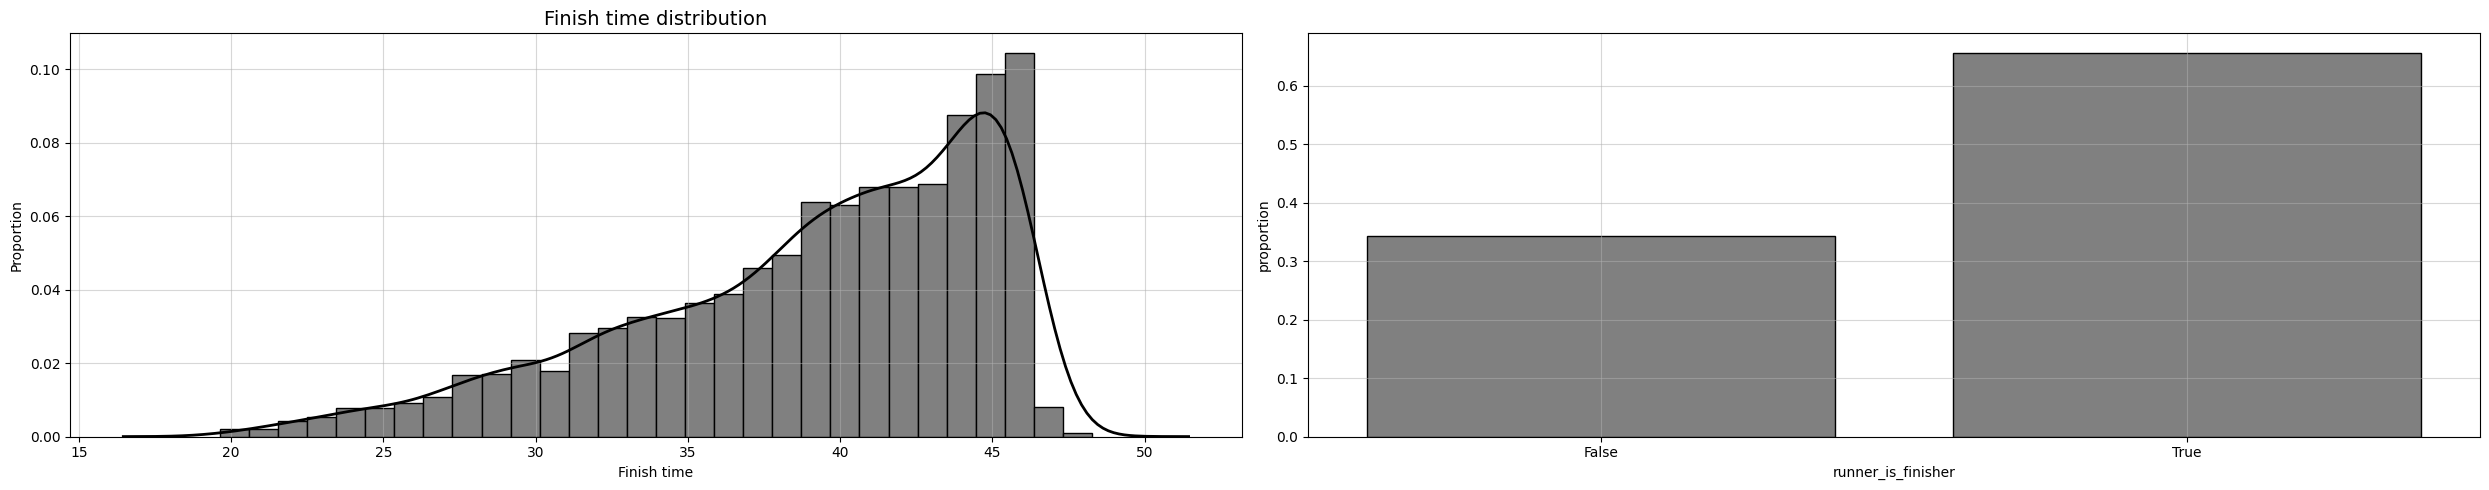

In [8]:
# Finish time distribution & DNF proportion distribution
fix, ax = plt.subplots(1,2, figsize=(25,5))

ax[0].set_title("Succesfull Finish distribution", fontsize=14)
prop_df = race_results_runner_statistics_train["runner_is_finisher"].value_counts(normalize=True) .reset_index()
sns.barplot(x="runner_is_finisher", y="proportion", data=prop_df, color="grey", edgecolor="black", ax=ax[1])
ax[0].set_xlabel("Finisher")
ax[0].set_ylabel("Proportion")


ax[0].set_title("Finish time distribution", fontsize=14)
ax[0].hist(race_results_runner_statistics_finished_train["runner_race_time_hours"], bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
sns.kdeplot(race_results_runner_statistics_finished_train["runner_race_time_hours"], ax=ax[0], color="black", linewidth=2)
ax[0].set_xlabel("Finish time")

for i in [0,1]:
    ax[i].grid(alpha=.5)

plt.tight_layout()
plt.show()

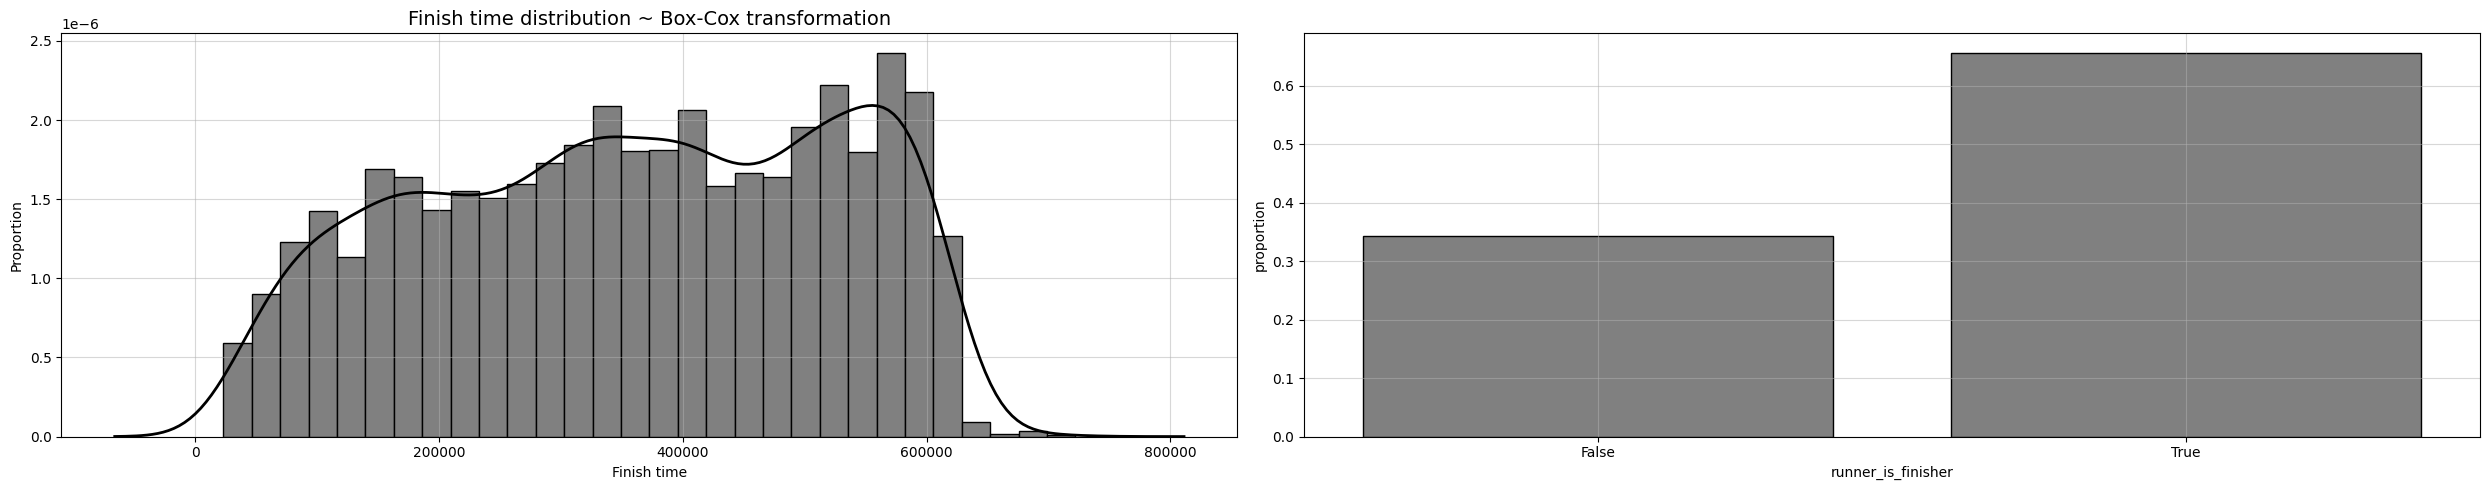

In [9]:
# Box-Cox Finish time distribution & DNF proportion distribution

target = race_results_runner_statistics_finished_train["runner_race_time_hours"]
lambda_bc = boxcox_normmax(target)
target_bc = boxcox(target, lmbda=lambda_bc)

fix, ax = plt.subplots(1,2, figsize=(25,5))

ax[0].set_title("Succesfull Finish distribution", fontsize=14)
prop_df = race_results_runner_statistics_train["runner_is_finisher"].value_counts(normalize=True) .reset_index()
sns.barplot(x="runner_is_finisher", y="proportion", data=prop_df, color="grey", edgecolor="black", ax=ax[1])
ax[0].set_xlabel("Finisher")
ax[0].set_ylabel("Proportion")


ax[0].set_title("Finish time distribution ~ Box-Cox transformation", fontsize=14)
ax[0].hist(target_bc, bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
sns.kdeplot(target_bc, ax=ax[0], color="black", linewidth=2)
ax[0].set_xlabel("Finish time")

for i in [0,1]:
    ax[i].grid(alpha=.5)

plt.tight_layout()
plt.show()

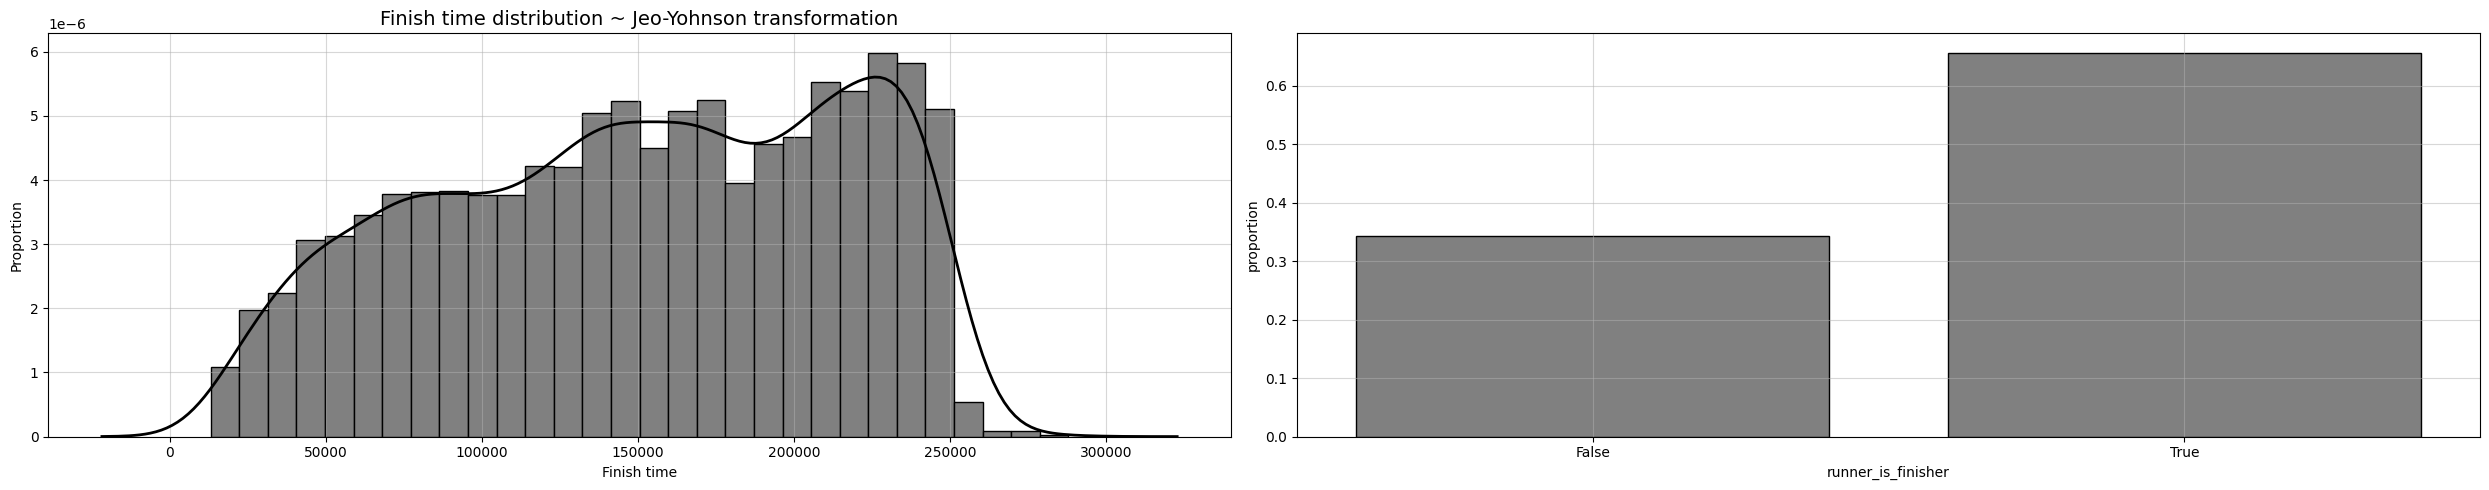

In [10]:
# Yeo-Johnson Finish time distribution & DNF proportion distribution
pt = PowerTransformer(method="yeo-johnson", standardize=False)
target = race_results_runner_statistics_finished_train["runner_race_time_hours"]
target_pt = pt.fit_transform(target.values.reshape(-1, 1)).flatten()

fix, ax = plt.subplots(1,2, figsize=(25,5))

ax[0].set_title("Succesfull Finish distribution", fontsize=14)
prop_df = race_results_runner_statistics_train["runner_is_finisher"].value_counts(normalize=True) .reset_index()
sns.barplot(x="runner_is_finisher", y="proportion", data=prop_df, color="grey", edgecolor="black", ax=ax[1])
ax[0].set_xlabel("Finisher")
ax[0].set_ylabel("Proportion")


ax[0].set_title("Finish time distribution ~ Jeo-Yohnson transformation", fontsize=14)
ax[0].hist(target_pt, bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
sns.kdeplot(target_pt, ax=ax[0], color="black", linewidth=2)
ax[0].set_xlabel("Finish time")

for i in [0,1]:
    ax[i].grid(alpha=.5)

plt.tight_layout()
plt.show()

In [11]:
# Box-Cox transform finish times & Yeo-Johnson (PT) finish times

# Box-Cox
target_bc = race_results_runner_statistics_finished_train["runner_race_time_hours"]
lambda_bc = boxcox_normmax(target_bc)
race_results_runner_statistics_finished_train["runner_race_time_hours_bc"] = boxcox(target_bc, lmbda=lambda_bc)
race_results_runner_statistics_finished_train["runner_race_time_hours_inverse_bc"] = inv_boxcox(race_results_runner_statistics_finished_train["runner_race_time_hours_bc"], lambda_bc)

# Yeo-Johnson
pt = PowerTransformer(method="yeo-johnson", standardize=False)
target_pt =  race_results_runner_statistics_finished_train["runner_race_time_hours"]
race_results_runner_statistics_finished_train["runner_race_time_hours_pt"] = pt.fit_transform(target_pt.values.reshape(-1, 1)).flatten()
race_results_runner_statistics_finished_train["runner_race_time_hours_inverse_pt"] = pt.inverse_transform(race_results_runner_statistics_finished_train["runner_race_time_hours_pt"].values.reshape(-1, 1)).flatten()

---
### Race Finish Success ~ Univariate Logistic model

Help functions

In [ ]:
# Univariate Logit numeric feature ~ Help function

def univariate_logit_numeric(
        target: str, target_name: str, 
        feature: str, feature_name: str, 
        data: pd.DataFrame, 
        alpha: float=1.0,
        print_metrics: bool=True,
        show_plot: bool=True
        ) -> pd.DataFrame:
    
    if (print_metrics or show_plot) == True:
        print("-----------------------------------------------------")
        print(f"{target_name} ~ {feature_name} ~> Univariate Logistic Regression")
        print("-----------------------------------------------------\n")

    # Prepare data for modeling
    data = data.copy()

    data_clean = data[[target, feature]].replace([np.inf, -np.inf], np.nan).dropna()
    X = sm.add_constant(data_clean[[feature]])
    y = data_clean[target]

    # Model
    model = sm.Logit(y, X)
    fit = model.fit(disp=False)
    y_pred_prob = fit.predict(X)

    # Metrics
    scaling_factor = np.std(data_clean[feature]) / np.std(data_clean[target])
    metrics = {
        "coef": fit.params[feature],
        "scaled coef": fit.params[feature] * scaling_factor,
        "coef OR": np.exp(fit.params[feature]),
        "scaled coef OR": np.exp(fit.params[feature] * scaling_factor),
        "p-value": fit.pvalues[feature],
        "standard error": fit.bse[feature],
        "scaled standard error": fit.bse[feature] * scaling_factor,
        "confidence interval": round(fit.conf_int().loc[feature], 4).tolist(),
        "scaled confidence interval": round(fit.conf_int().loc[feature] * scaling_factor, 4).tolist(),
        "confidence interval OR": round(np.exp(fit.conf_int().loc[feature]), 4).tolist(),
        "scaled confidence interval OR": round(np.exp(fit.conf_int().loc[feature] * scaling_factor), 4).tolist(),
        "Pseudo R2": fit.prsquared,
        "Log-Likelihood": fit.llf,
        "Likelihood Ratio (Chi2)": fit.llr,
        "Chi2 test p-value": fit.llr_pvalue ,
        "AIC": fit.aic,
        "BIC": fit.bic,
        "AUC": roc_auc_score(y, y_pred_prob),
    }

    metrics_df = pd.DataFrame([metrics])
    metrics_df.insert(0, "feature", feature)

    if print_metrics:
        for key, value in metrics.items():
            if isinstance(value, list):
                print(f"{key} ~> {[f'{v:.4f}' for v in value]}")
            else:
                print(f"{key} ~> {value:.4f}" if isinstance(value, float) else f"{key} ~> {value}")

    # Plot
    if show_plot:
        fig, ax = plt.subplots(2, 2, figsize=(25, 10))

        # Feature distribution
        ax[0,0].set_title(f"{feature_name} Distribution", fontsize=14)
        ax[0,0].hist(data_clean[feature], bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
        sns.kdeplot(data_clean[feature], ax=ax[0,0], color="black", linewidth=2)
        ax[0,0].set_xlabel(feature_name)

        # Predicted probabilities distribution in comparison to actual values
        ax[0,1].set_title(f"Predicted Probability Distribution ~ {target_name} ", fontsize=14, alpha=.8)
        sns.violinplot(
            x=y, y=y_pred_prob, hue=y,
            split = False, inner="quartile", palette={0: "#3898FF", 1: "#FF4040"}, ax=ax[0,1]
        )
        ax[0,1].set_xlabel("Actual Boolean")
        ax[0,1].set_ylabel("Predicted probability")
        ax[0,1].get_legend().remove()

        # Logistic curve
        ax[1,0].set_title(f"{target_name} ~ {feature_name} ~ Logistic curve")
        sorted_idx = np.argsort(data_clean[feature])
        ax[1,0].scatter(data_clean[feature], y, color="black", alpha=alpha, label="Observed")
        ax[1,0].plot(data_clean[feature].iloc[sorted_idx], y_pred_prob.iloc[sorted_idx], color="red", linewidth=2, label="Logistic fit")
        ax[1,0].set_xlabel(feature_name)
        ax[1,0].set_ylabel("Predicted Probability = 1")
        ax[1,0].legend()

        # ROC and AUC
        ax[1,1].set_title("ROC Curve", fontsize=14)
        fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
        auc_score = roc_auc_score(y, y_pred_prob)
        ax[1,1].plot(fpr, tpr, color="black", label=f"ROC curve, AUC = {auc_score:.3f}")
        ax[1,1].plot([0, 1], [0, 1], color="blue", linestyle="--", label="Random classifier")
        ax[1,1].set_xlabel("False Positive Rate")
        ax[1,1].set_ylabel("True Positive Rate")
        ax[1,1].legend(fontsize=14)

        for i in [0,1]:
            for j in [0,1]:
                ax[i,j].grid(alpha=.5)

        plt.tight_layout()
        plt.show()

    return metrics_df


In [ ]:
# Univariate Logit categorical feature ~ Help function

def univariate_logit_categorical(
        target: str, target_name: str, 
        feature: str, feature_name: str, 
        data: pd.DataFrame, 
        alpha: float=1.0,
        print_metrics: bool=True,
        show_plot: bool=True
        ) -> pd.DataFrame:
    
    if (print_metrics or show_plot) == True:
        print("-----------------------------------------------------")
        print(f"{target_name} ~ {feature_name} ~> Univariate Logistic Regression")
        print("-----------------------------------------------------\n")

    # Prepare data for modeling
    data = data.copy()

    # Dummies
    dummies = pd.get_dummies(data[feature], prefix=feature, drop_first=True).astype(int)
    data = pd.concat([data, dummies], axis=1)
    dummies_names = list(dummies.columns)

    data_clean = data[[target] + dummies_names].replace([np.inf, -np.inf], np.nan).dropna()
    X = sm.add_constant(data_clean[dummies_names])
    y = data_clean[target]

    # Model
    model = sm.Logit(y, X)
    fit = model.fit(disp=False)
    y_pred_prob = fit.predict(X)

    # Metrics
    metrics_full = {}
    for dummy in dummies_names:
        scaling_factor = np.std(data_clean[dummy]) / np.std(data_clean[target])
        metrics_dummy = {
            "coef": fit.params[dummy],
            "scaled coef": fit.params[dummy] * scaling_factor,
            "coef OR": np.exp(fit.params[dummy]),
            "scaled coef OR": np.exp(fit.params[dummy] * scaling_factor),
            "p-value": fit.pvalues[dummy],
            "standard error": fit.bse[dummy],
            "scaled standard error": fit.bse[dummy] * scaling_factor,
            "confidence interval": round(fit.conf_int().loc[dummy], 4).tolist(),
            "scaled confidence interval": round(fit.conf_int().loc[dummy] * scaling_factor, 4).tolist(),
            "confidence interval OR": round(np.exp(fit.conf_int().loc[dummy]), 4).tolist(),
            "scaled confidence interval OR": round(np.exp(fit.conf_int().loc[dummy] * scaling_factor), 4).tolist(),
            "Pseudo R2": fit.prsquared,
            "Log-Likelihood": fit.llf,
            "Likelihood Ratio (Chi2)": fit.llr,
            "Chi2 test p-value": fit.llr_pvalue ,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "AUC": roc_auc_score(y, y_pred_prob),
        }

        metrics_full[dummy] = metrics_dummy

    if print_metrics:
        for metric in metrics_full[dummies_names[0]]:
            values = [metrics_full[dummy][metric] for dummy in dummies_names]

            if isinstance(values[0], (list, tuple)):
                row_str = " ".join([
                    f"[{dummy} = {[f'{v:.4f}' for v in val]}]" 
                    for dummy, val in zip(dummies_names, values)
                    ])
                
            else:  
                row_str = ", ".join([
                    f"[{dummy} = {[f'{v:.4f}' for v in metrics_full[dummy][metric]]}]"
                    if isinstance(metrics_full[dummy][metric], (list, tuple))
                    else f"[{dummy} = {metrics_full[dummy][metric]:.4f}]"
                    for dummy in dummies_names
                ])

            print(f"{metric} ~> {row_str}")

    # Plot
    if show_plot:
        fig, ax = plt.subplots(2, 2, figsize=(25, 10))

        # Feature distribution
        ax[0,0].set_title(f"{feature_name} Distribution", fontsize=14)
        prop_df = data[feature].value_counts(normalize=True) .reset_index()
        sns.barplot(x=feature, y="proportion", data=prop_df, color="grey", edgecolor="black", ax=ax[0,0])
        ax[0,0].set_xlabel(feature_name)

        # Predicted probabilities distribution in comparison to actual values
        ax[0,1].set_title(f"{target_name} ~ {feature_name} ~> Distribution", fontsize=14, alpha=.8)
        sns.violinplot(
            x=y, y=y_pred_prob, hue=y,
            split = False, inner="quartile", palette={0: "#3898FF", 1: "#FF4040"}, ax=ax[0,1]
        )
        ax[0,1].set_xlabel("Actual Boolean")
        ax[0,1].set_ylabel("Predicted probability")
        ax[0,1].get_legend().remove()

        # "Logistic curve"
        ax[1,0].set_title(f"Predicted Probability Distribution ~ {target_name} ")
        pred_prob_by_cat = pd.concat([data[feature], pd.Series(y_pred_prob, index=data.index)], axis=1)
        sns.pointplot(x=feature, y=y_pred_prob, data=pred_prob_by_cat, ax=ax[1,0], color="red")
        ax[1,0].set_xlabel(feature_name)
        ax[1,0].set_ylabel("Predicted Probability = 1")
        ax[1,0].legend()

        # ROC and AUC
        ax[1,1].set_title("ROC Curve", fontsize=14)
        fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
        auc_score = roc_auc_score(y, y_pred_prob)
        ax[1,1].plot(fpr, tpr, color="black", label=f"ROC curve, AUC = {auc_score:.3f}")
        ax[1,1].plot([0, 1], [0, 1], color="blue", linestyle="--", label="Random classifier")
        ax[1,1].set_xlabel("False Positive Rate")
        ax[1,1].set_ylabel("True Positive Rate")
        ax[1,1].legend(fontsize=14)

        for i in [0,1]:
            for j in [0,1]:
                ax[i,j].grid(alpha=.5)

        plt.tight_layout()
        plt.show()

    metrics_df = pd.DataFrame(metrics_full).T.reset_index().rename(columns={"index": "feature"})
    return metrics_df


Quick run through "feature importances"

In [14]:
# Univariate analysis for all features and save metrics

# Features we want to perform univariate analysis on
features_to_analyse = [
    col for col in race_results_runner_statistics_train.columns if 
        "alltime" in col or 
        "last2years" in col or 
        col in ["runner_pre_race_index", "runner_gender", "runner_age"]
 ]

race_finisher_features_metrics_list = []
for single_feature in features_to_analyse:

    # Numeric features
    if pd.api.types.is_numeric_dtype(race_results_runner_statistics_train[single_feature]):
        try:
            single_feature_metrics = univariate_logit_numeric(
                target = "runner_is_finisher", target_name = "Finisher",
                feature = single_feature, feature_name = "Feature",
                data = race_results_runner_statistics_train,
                alpha = 0.1,
                print_metrics = False,
                show_plot = False
                )
        except:
            print("Problems for {}".format(single_feature))
    
    # Categorical features
    else:
        try:
            single_feature_metrics = univariate_logit_categorical(
                target = "runner_is_finisher", target_name = "Finisher",
                feature = single_feature, feature_name = "Feature",
                data = race_results_runner_statistics_train,
                alpha = 0.1,
                print_metrics = False,
                show_plot = False
                )
        except:
            print("Problems for {}".format(single_feature))

    # Save feature metrics DataFrame into a list
    race_finisher_features_metrics_list.append(single_feature_metrics)

# Combine all features metrics into a DataFrame
race_finisher_features_metrics_df = pd.concat(race_finisher_features_metrics_list, ignore_index=True)

In [15]:
# Check
race_finisher_features_metrics_df = race_finisher_features_metrics_df.sort_values(
    by="scaled coef", 
    key=lambda x: x.abs(), 
    ascending=False
    ).reset_index(drop=True)

race_finisher_features_metrics_df

,feature,coef,scaled coef,coef OR,scaled coef OR,p-value,standard error,scaled standard error,confidence interval,scaled confidence interval,confidence interval OR,scaled confidence interval OR,Pseudo R2,Log-Likelihood,Likelihood Ratio (Chi2),Chi2 test p-value,AIC,BIC,AUC
0,alltime_alldist_finish_prop,6.566108,1.04938,710.598717,2.85588,0.0,0.328537,0.052506,"[5.9222, 7.21]","[0.9465, 1.1523]","[373.2269, 1352.9316]","[2.5766, 3.1654]",0.042564,-4955.336687,440.593578,0.0,9914.673375,9928.660726,0.634771
1,alltime_100m_finish_prop,1.768196,0.903258,5.860271,2.467629,0.0,0.104503,0.053384,"[1.5634, 1.973]","[0.7986, 1.0079]","[4.7749, 7.1923]","[2.2225, 2.7398]",0.033082,-4400.454826,301.116099,0.0,8804.909652,8818.644225,0.616489
2,last2years_100m_finish_prop,1.290494,0.859155,3.634581,2.361165,0.0,0.088484,0.058909,"[1.1171, 1.4639]","[0.7437, 0.9746]","[3.0559, 4.3229]","[2.1037, 2.6501]",0.030117,-3456.829033,214.6859,0.0,6917.658067,6930.944308,0.598019
3,alltime_alldist_avg_finisher_rank_prop_gender_...,1.19751,0.833313,3.31186,2.300929,0.000148,0.31558,0.219603,"[0.579, 1.816]","[0.4029, 1.2637]","[1.7842, 6.1474]","[1.4962, 3.5386]",0.001693,-5166.872561,17.521831,0.000028,10337.745122,10351.732474,0.551327
4,last2years_alldist_avg_finisher_rank_prop,1.4388,0.817163,4.215634,2.264067,0.0,0.09089,0.051621,"[1.2607, 1.6169]","[0.716, 0.9183]","[3.5277, 5.0377]","[2.0462, 2.5051]",0.025759,-4931.302461,260.766547,0.0,9866.604922,9880.554665,0.601228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,last2years_100m_utmb_index_trend,0.000036,0.007573,1.000036,1.007601,0.878292,0.000235,0.049451,"[-0.0004, 0.0005]","[-0.0893, 0.1045]","[0.9996, 1.0005]","[0.9145, 1.1101]",0.000002,-5175.621753,0.023446,0.878303,10355.243507,10369.230858,0.543523
143,alltime_sub100k_avg_finisher_rank_prop_trend,0.001216,0.005523,1.001216,1.005538,0.911622,0.010951,0.049761,"[-0.0202, 0.0227]","[-0.092, 0.1031]","[0.98, 1.0229]","[0.9121, 1.1085]",0.000001,-5175.627289,0.012376,0.911421,10355.254577,10369.241929,0.53958
144,alltime_sub100k_utmb_index_trend,0.000003,0.003957,1.000003,1.003965,0.936134,0.000035,0.049379,"[-0.0001, 0.0001]","[-0.0928, 0.1007]","[0.9999, 1.0001]","[0.9114, 1.106]",0.000001,-5175.630269,0.006414,0.936166,10355.260539,10369.24789,0.551474
145,alltime_alldist_sd_finisher_rank_prop_gender,-0.027119,-0.003766,0.973246,0.996241,0.939479,0.357182,0.049602,"[-0.7272, 0.6729]","[-0.101, 0.0935]","[0.4833, 1.96]","[0.9039, 1.098]",0.000001,-5151.405319,0.005765,0.939479,10306.810637,10320.789027,0.505098


---
### Race Finish Success - Full model

Help functions

In [ ]:
# Full Train & Test Logit model ~ Help function

def full_Logit_model_analysis(
        target_dict: Dict[str, str],
        features_dict: Dict[str, str],
        train_data: pd.DataFrame, 
        test_data: pd.DataFrame,
        alpha: float=1.0,
        print_metrics: bool=True,
        show_plot: bool=True
        ) -> Dict[str, any]:

    # -------------------------------------------------------------
    # -------------------------------------------------------------

    target = list(target_dict.keys())[0]
    target_name = list(target_dict.values())[0]

    features = list(features_dict.keys())
    features_names = list(features_dict.values())
        
    if (print_metrics or show_plot) == True:
        print("-----------------------------------------------------")
        print(f"{target_name} ~\n{" + \n".join(features_names)} \n~> Logistic regression")
        print("-----------------------------------------------------\n")

    # Prepare data for modeling
    train_data = train_data.copy()
    test_data = test_data.copy()

    train_data_clean = train_data[[target] + features].replace([np.inf, -np.inf], np.nan).dropna()
    X_train = sm.add_constant(train_data_clean[features])
    y_train = train_data_clean[target]

    test_data_clean = test_data[[target] + features].dropna() 
    X_test = sm.add_constant(test_data_clean[features])
    y_test = test_data_clean[target]

    # Model
    model = sm.Logit(y_train, X_train)
    fit = model.fit()

    y_pred_prob_train = fit.predict(X_train)
    y_pred_prob_test = fit.predict(X_test)

    # Metrics
    X_train_no_const = X_train.drop(columns="const", errors="ignore").copy()
    vif_train = pd.DataFrame({
        "feature": X_train_no_const.columns,
        "VIF": [variance_inflation_factor(X_train_no_const.values, i) for i in range(X_train_no_const.shape[1])]
        })

    train_model_metrics = {
        "Pseudo R2": fit.prsquared,
        "Log-Likelihood": fit.llf,
        "Likelihood Ratio (Chi2)": fit.llr,
        "Chi2 test p-value": fit.llr_pvalue ,
        "AIC": fit.aic,
        "BIC": fit.bic,
        "AUC": roc_auc_score(y_train, y_pred_prob_train),
    }
    train_model_metrics_df = pd.DataFrame([train_model_metrics])

    ll_model_test = log_likelihood(y_test, y_pred_prob_test)
    ll_null_test = log_likelihood(y_test, np.full_like(y_test, y_test.mean()))
    nr_features = len(features)
    nr_samples_test = len(y_test)
    test_model_metrics = {
        "Pseudo R2": 1 - (ll_model_test / ll_null_test),
        "Log-Likelihood": ll_model_test,
        "Likelihood Ratio (Chi2)": 2 * (ll_model_test - ll_null_test),
        "Chi2 test p-value": 1 - chi2.cdf(2 * (ll_model_test - ll_null_test), df=nr_features),
        "AIC": 2 * nr_features - 2 * ll_model_test,
        "BIC": np.log(nr_samples_test) * nr_features - 2 * ll_model_test,
        "AUC": roc_auc_score(y_test, y_pred_prob_test),
    }
    test_model_metrics_df = pd.DataFrame([test_model_metrics])

    features_metrics = []
    for single_feature in features:
        scaling_factor = np.std(train_data_clean[single_feature]) / np.std(train_data_clean[target])
        single_feature_metrics = {
            "feature": single_feature,
            "feature name": features_dict[single_feature],
            "coef": fit.params[single_feature],
            "scaled coef": fit.params[single_feature] * scaling_factor,
            "coef OR": np.exp(fit.params[single_feature]),
            "scaled coef OR": np.exp(fit.params[single_feature] * scaling_factor),
            "p-value": fit.pvalues[single_feature],
            "standard error": fit.bse[single_feature],
            "scaled standard error": fit.bse[single_feature] * scaling_factor,
            "confidence interval": round(fit.conf_int().loc[single_feature], 4).tolist(),
            "scaled confidence interval": round(fit.conf_int().loc[single_feature] * scaling_factor, 4).tolist(),
            "confidence interval OR": round(np.exp(fit.conf_int().loc[single_feature]), 4).tolist(),
            "scaled confidence interval OR": round(np.exp(fit.conf_int().loc[single_feature] * scaling_factor), 4).tolist(),
            "VIF": vif_train.loc[vif_train["feature"] == single_feature, "VIF"].values[0]
        }
        features_metrics.append(single_feature_metrics)
    features_metrics_df = pd.DataFrame(features_metrics)

    if print_metrics:

        print("\nModel metrics on Train data:")
        print("------------------------------------")
        for key, value in train_model_metrics.items():
            if isinstance(value, list):
                print(f"{key} ~> {[f'{v:.4f}' for v in value]}")
            else:
                print(f"{key} ~> {value:.4f}" if isinstance(value, float) else f"{key} ~> {value}")

        print("\nModel metrics on Test data:")
        print("------------------------------------")
        for key, value in test_model_metrics.items():
            if isinstance(value, list):
                print(f"{key} ~> {[f'{v:.4f}' for v in value]}")
            else:
                print(f"{key} ~> {value:.4f}" if isinstance(value, float) else f"{key} ~> {value}")

        print("\nFeatures metrics:")
        display(features_metrics_df)

    # Plot
    if show_plot:
        fig, ax = plt.subplots(2, 2, figsize=(25, 10))

        # Predicted proability distribution
        ax[0].set_title("Predicted Probability Distribution ~ Test data")
        ax[0].hist(y_pred_prob_test, bins=30, color="grey", edgecolor="black", density=True)
        sns.kdeplot(y_pred_prob_test, ax=ax[0], color="black", linewidth=2)
        ax[0].set_xlabel("Predicted probability")
        ax[0].set_ylabel("Density")

        # Predicted probabilities distribution in comparison to actual values
        ax[0,0].set_title(f"Predicted Probability Distribution ~ {target_name} ~ Test data", fontsize=14, alpha=.8)
        sns.violinplot(
            x=y_test, y=y_pred_prob_test, hue=y_test,
            split = False, inner="quartile", palette={0: "#3898FF", 1: "#FF4040"}, ax=ax[0,0]
        )
        ax[0,0].set_xlabel("Actual Boolean")
        ax[0,0].set_ylabel("Predicted probability")
        ax[0,0].get_legend().remove()

        # ROC and AUC
        ax[1,0].set_title("ROC Curve ~ Test data", fontsize=14)
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_test)
        auc_score = roc_auc_score(y_test, y_pred_prob_test)
        ax[1,0].plot(fpr, tpr, color="black", label=f"ROC curve, AUC = {auc_score:.3f}")
        ax[1,0].plot([0, 1], [0, 1], color="blue", linestyle="--", label="Random classifier")
        ax[1,0].set_xlabel("False Positive Rate")
        ax[1,0].set_ylabel("True Positive Rate")
        ax[1,0].legend(fontsize=14)

        # Residuals plot
        ax[1,1].set_title("Residuals vs Predicted ~ Train data")
        residuals_train = y_train - y_pred_prob_train
        ax[1,1].scatter(y_pred_prob_train, residuals_train, color="black", alpha=0.5)
        ax[1,1].axhline(0, color="red", linestyle="--")
        ax[1,1].set_xlabel("Predicted probability")
        ax[1,1].set_ylabel("Residuals")

        for i in [0,1]:
            for j in [0,1]:
                ax[i,j].grid(alpha=.5)

        plt.tight_layout()
        plt.show()

    # Return
    metrics = {
        "fit": fit,
        "features": features,
        "train_model_metrics": train_model_metrics_df,
        "test_model_metrics": test_model_metrics_df,
        "features_metrics": features_metrics_df,
    }

    return metrics


---
### Race Finish time ~ Univariate Linear model

Help functions

In [16]:
# Univariate OLS numeric feature ~ Help function

def univariate_OLS_numeric(
        target: str, target_name: str, 
        feature: str, feature_name: str, 
        data: pd.DataFrame, 
        alpha: float=1.0,
        box_cox_transformation: bool=False, 
        print_metrics: bool=True,
        show_plot: bool=True
        ) -> pd.DataFrame:
    
    if (print_metrics or show_plot) == True:
        print("-----------------------------------------------------")
        print(f"{target_name} ~ {feature_name} ~> Univariate Linear Regression")
        print("-----------------------------------------------------\n")

    # Prepare data for modeling
    data = data.copy()

    if box_cox_transformation:
        target_name = target_name + " [Box-Cox Transformed]"
        target_bc = data[target]
        lambda_bc = boxcox_normmax(target_bc)
        data[target+"_bc"] = boxcox(target_bc, lmbda=lambda_bc)
        target = target+"_bc"

    data_clean = data[[target, feature]].replace([np.inf, -np.inf], np.nan).dropna()
    X = sm.add_constant(data_clean[[feature]])
    y = data_clean[target]

    # Model
    model = sm.OLS(y, X)
    fit = model.fit()
    y_pred = fit.predict(X)

    if box_cox_transformation:
        prop_clipped = round((y_pred < 1e-6).mean(), 2)
        y_pred = np.where(y_pred < 1e-6, 1e-6, y_pred)
        
        y_pred = inv_boxcox(y_pred, lambda_bc)
        y = inv_boxcox(y, lambda_bc)

    # Metrics
    scaling_factor = np.std(data_clean[feature]) / np.std(data_clean[target])
    metrics = {
        "proportion of clipped Box-Cox predicted values": prop_clipped if box_cox_transformation else None,
        "coef": fit.params[feature],
        "scaled coef": fit.params[feature] * scaling_factor,
        "p-value": fit.pvalues[feature],
        "standard error": fit.bse[feature],
        "scaled standard error": fit.bse[feature] * scaling_factor,
        "confidence interval": round(fit.conf_int().loc[feature], 4).tolist(),
        "scaled confidence interval": round(fit.conf_int().loc[feature] * scaling_factor, 4).tolist(),
        "R2": fit.rsquared,
        "R2 adjusted": fit.rsquared_adj,
        "MAE": mean_absolute_error(y, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y, y_pred)),
        "Pearson correlation coefficient": pearsonr(y, y_pred)[0]
    }

    metrics_df = pd.DataFrame([metrics])
    metrics_df.insert(0, "feature", feature)

    if print_metrics:
        for key, value in metrics.items():
            if isinstance(value, list):
                print(f"{key} ~> {[f'{v:.4f}' for v in value]}")
            else:
                print(f"{key} ~> {value:.4f}" if isinstance(value, float) else f"{key} ~> {value}")

    # Plot
    if show_plot:
        fig, ax = plt.subplots(2, 2, figsize=(25, 10))

        # Feature distribution
        ax[0,0].set_title(f"{feature_name} Distribution", fontsize=14)
        ax[0,0].hist(data_clean[feature], bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
        sns.kdeplot(data_clean[feature], ax=ax[0,0], color="black", linewidth=2)
        ax[0,0].set_xlabel(feature_name)

        # Scatter plot with regression line
        ax[0,1].set_title(f"{target_name} ~ {feature_name} ~> Scatter plot & Regression line", fontsize=14)
        ax[0,1].scatter(data_clean[feature], data_clean[target], color="black", s=15, alpha=alpha)
        sns.regplot(x=data_clean[feature], y=data_clean[target], ax=ax[0,1], scatter=False, line_kws={"color":"red", "linewidth":2})
        ax[0,1].set_xlabel(feature_name)
        ax[0,1].set_ylabel(target_name)

        # Residuals scatter ~ Linearity assumption, Homoscedasticity, Outliers, Centering around zero
        ax[1,0].set_title("Predicted values vs. Residuals", fontsize=14)
        residuals = y - y_pred
        ax[1,0].scatter(y_pred, residuals, color="black", s=15, alpha=alpha)
        ax[1,0].axhline(0, color="red", linestyle="--")
        ax[1,0].set_xlabel("Predictions")
        ax[1,0].set_ylabel("Residuals")

        # Residuals KDE ~ Normality assumption
        ax[1,1].set_title("Residuals distribution", fontsize=14)
        ax[1,1].hist(residuals, bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
        sns.kdeplot(residuals, ax=ax[1,1], color="black", linewidth=2)
        ax[1,1].set_xlabel("Residuals")
        ax[1,1].set_ylabel("Density")

        for i in [0,1]:
            for j in [0,1]:
                ax[i,j].grid(alpha=.5)

        plt.tight_layout()
        plt.show()

    return metrics_df


In [23]:
# Univariate OLS categorical feature ~ Help function

def univariate_OLS_categorical(
        target: str, target_name: str, 
        feature: str, feature_name: str, 
        data: pd.DataFrame, 
        alpha: float=1.0,
        box_cox_transformation: bool=False, 
        print_metrics: bool=True,
        show_plot: bool=True
        ) -> pd.DataFrame:
    
    if (print_metrics or show_plot) == True:
        print("-----------------------------------------------------")
        print(f"{target_name} ~ {feature_name} ~> Univariate Linear Regression")
        print("-----------------------------------------------------\n")

    # Prepare data for modeling
    data = data.copy()

    if box_cox_transformation:
        target_name = target_name + " [Box-Cox Transformed]"
        target_bc = data[target]
        lambda_bc = boxcox_normmax(target_bc)
        data[target+"_bc"] = boxcox(target_bc, lmbda=lambda_bc)
        target = target+"_bc"

    dummies = pd.get_dummies(data[feature], prefix=feature, drop_first=True).astype(int)
    data = pd.concat([data, dummies], axis=1)
    dummies_names = list(dummies.columns)

    data_clean = data[[target] + dummies_names].replace([np.inf, -np.inf], np.nan).dropna()
    X = sm.add_constant(data_clean[dummies_names])
    y = data_clean[target]

    # Model
    model = sm.OLS(y, X)
    fit = model.fit()
    y_pred = fit.predict(X)

    if box_cox_transformation:
        prop_clipped = round((y_pred < 1e-6).mean(), 2)
        y_pred = np.where(y_pred < 1e-6, 1e-6, y_pred)
        
        y_pred = inv_boxcox(y_pred, lambda_bc)
        y = inv_boxcox(y, lambda_bc)

    # Metrics
    metrics_full = {}
    for dummy in dummies_names:
        scaling_factor = np.std(data_clean[dummy]) / np.std(data_clean[target])
        metrics_dummy = {
            "proportion of clipped Box-Cox predicted values": prop_clipped if box_cox_transformation else None,
            "coef": fit.params[dummy],
            "scaled coef": fit.params[dummy] * scaling_factor,
            "p-value": fit.pvalues[dummy],
            "standard error": fit.bse[dummy],
            "scaled standard error": fit.bse[dummy] * scaling_factor,
            "confidence interval": round(fit.conf_int().loc[dummy], 4).tolist(),
            "scaled confidence interval": round(fit.conf_int().loc[dummy] * scaling_factor, 4).tolist(),
            "R2": fit.rsquared,
            "R2 adjusted": fit.rsquared_adj,
            "MAE": mean_absolute_error(y, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y, y_pred)),
            "Pearson correlation coefficient": pearsonr(y, y_pred)[0]
        }

        metrics_full[dummy] = metrics_dummy

    def format_metric(val):
        if isinstance(val, (list, tuple)):
            return f"[{', '.join(f'{v:.4f}' for v in val)}]"
        elif val is None:
            return "None"
        else:
            return f"{val:.4f}"

    if print_metrics:
        for metric in metrics_full[dummies_names[0]]:
            row_str = ", ".join([f"[{dummy} = {format_metric(metrics_full[dummy][metric])}]" for dummy in dummies_names])
            print(f"{metric} ~> {row_str}")

    # Plot
    if show_plot:
        fig, ax = plt.subplots(2, 2, figsize=(25, 10))

        # Feature distribution
        ax[0,0].set_title(f"{feature_name} Distribution", fontsize=14)
        prop_df = data[feature].value_counts(normalize=True) .reset_index()
        sns.barplot(x=feature, y="proportion", data=prop_df, color="grey", edgecolor="black", ax=ax[0,0])
        ax[0,0].set_xlabel(feature_name)

        # Scatter plot with regression line
        ax[0,1].set_title(f"{target_name} ~ {feature_name} ~> Scatter plot & Regression line", fontsize=14)
        ax[0,1].scatter(data_clean[dummies_names], data_clean[target], color="black", s=15, alpha=alpha)
        sns.regplot(x=data_clean[dummies_names], y=data_clean[target], ax=ax[0,1], scatter=False, line_kws={"color":"red", "linewidth":2})
        ax[0,1].set_xlabel(feature_name)
        ax[0,1].set_ylabel(target_name)

        # Residuals scatter ~ Linearity assumption, Homoscedasticity, Outliers, Centering around zero
        ax[1,0].set_title("Predicted values vs. Residuals", fontsize=14)
        residuals = y - y_pred
        ax[1,0].scatter(y_pred, residuals, color="black", s=15, alpha=alpha)
        ax[1,0].axhline(0, color="red", linestyle="--")
        ax[1,0].set_xlabel("Predictions")
        ax[1,0].set_ylabel("Residuals")

        # Residuals KDE ~ Normality assumption
        ax[1,1].set_title("Residuals distribution", fontsize=14)
        ax[1,1].hist(residuals, bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
        sns.kdeplot(residuals, ax=ax[1,1], color="black", linewidth=2)
        ax[1,1].set_xlabel("Residuals")
        ax[1,1].set_ylabel("Density")

        for i in [0,1]:
            for j in [0,1]:
                ax[i,j].grid(alpha=.5)

        plt.tight_layout()
        plt.show()

    metrics_df = pd.DataFrame(metrics_full).T.reset_index().rename(columns={"index": "feature"})
    return metrics_df


Quick run through "feature importances"

In [18]:
# Univariate analysis for all features and save metrics

# Features we want to perform univariate analysis on
features_to_analyse = [
    col for col in race_results_runner_statistics_finished_train.columns if 
        "alltime" in col or 
        "last2years" in col or 
        col in ["runner_pre_race_index", "runner_gender", "runner_age"]
 ]

race_time_features_metrics_list = []
for single_feature in features_to_analyse:

    # Numeric features
    if pd.api.types.is_numeric_dtype(race_results_runner_statistics_finished_train[single_feature]):
        try:
            single_feature_metrics = univariate_OLS_numeric(
                target = "runner_race_time_hours", target_name = "Race Time",
                feature = single_feature, feature_name = "Feature",
                data = race_results_runner_statistics_finished_train,
                alpha = 0.1,
                box_cox_transformation = False, 
                print_metrics = False,
                show_plot = False
                )
        except:
            print("Problems for {}".format(single_feature))
    
    # Categorical features
    else:
        try:
            single_feature_metrics = univariate_OLS_categorical(
                target = "runner_race_time_hours", target_name = "Race Time",
                feature = single_feature, feature_name = "Feature",
                data = race_results_runner_statistics_finished_train,
                alpha = 0.1,
                box_cox_transformation = False, 
                print_metrics = False,
                show_plot = False
                )
        except:
            print("Problems for {}".format(single_feature))

    # Save feature metrics DataFrame into a list
    race_time_features_metrics_list.append(single_feature_metrics)

# Combine all features metrics into a DataFrame
race_time_features_metrics_df = pd.concat(race_time_features_metrics_list, ignore_index=True)

Problems for runner_gender


In [19]:
# Check
race_time_features_metrics_df = race_time_features_metrics_df.sort_values(
    by="scaled coef", 
    key=lambda x: x.abs(), 
    ascending=False
    ).reset_index(drop=True)

race_time_features_metrics_df

,feature,proportion of clipped Box-Cox predicted values,coef,scaled coef,p-value,standard error,scaled standard error,confidence interval,scaled confidence interval,R2,R2 adjusted,MAE,RMSE,Pearson correlation coefficient
0,last2years_alldist_avg_race_index,None,-0.054690,-0.854321,0.000000,0.000461,0.007197,"[-0.0556, -0.0538]","[-0.8684, -0.8402]",7.298638e-01,0.729812,2.404963,3.063375,0.854321
1,last2years_100m_avg_race_index,None,-0.051525,-0.850593,0.000000,0.000530,0.008752,"[-0.0526, -0.0505]","[-0.8678, -0.8334]",7.235087e-01,0.723432,2.506441,3.215201,0.850593
2,last2years_100k_avg_race_index,None,-0.051016,-0.845309,0.000000,0.000489,0.008106,"[-0.052, -0.0501]","[-0.8612, -0.8294]",7.145469e-01,0.714481,2.511237,3.199305,0.845309
3,alltime_100m_avg_race_index,None,-0.053515,-0.841543,0.000000,0.000508,0.007993,"[-0.0545, -0.0525]","[-0.8572, -0.8259]",7.081949e-01,0.708131,2.518544,3.239718,0.841543
4,alltime_alldist_avg_race_index,None,-0.059134,-0.837110,0.000000,0.000531,0.007520,"[-0.0602, -0.0581]","[-0.8519, -0.8224]",7.007537e-01,0.700697,2.526481,3.216474,0.837110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,alltime_sub100k_avg_finisher_rank_prop_trend,None,-0.003168,-0.001424,0.917531,0.030591,0.013748,"[-0.0631, 0.0568]","[-0.0284, 0.0255]",2.026560e-06,-0.000187,4.795634,5.879836,0.001424
143,last2years_sub100k_avg_finisher_rank_prop_gend...,None,-0.001573,-0.001416,0.917990,0.015278,0.013748,"[-0.0315, 0.0284]","[-0.0284, 0.0255]",2.003975e-06,-0.000187,4.795566,5.879836,0.001416
144,last2years_alldist_utmb_index_trend,None,-0.000054,-0.001109,0.935694,0.000675,0.013748,"[-0.0014, 0.0013]","[-0.0281, 0.0258]",1.230477e-06,-0.000188,4.795580,5.879838,0.001109
145,last2years_sub100k_avg_finisher_rank_prop_trend,None,0.001038,0.000919,0.946714,0.015523,0.013748,"[-0.0294, 0.0315]","[-0.026, 0.0279]",8.442827e-07,-0.000188,4.795634,5.879839,0.000919


Feature exploration

-----------------------------------------------------
Race Time ~ Gender ~> Univariate Linear Regression
-----------------------------------------------------

proportion of clipped Box-Cox predicted values ~> [runner_gender_H = None]
coef ~> [runner_gender_H = -0.4971]
scaled coef ~> [runner_gender_H = -0.0254]
p-value ~> [runner_gender_H = 0.0646]
standard error ~> [runner_gender_H = 0.2689]
scaled standard error ~> [runner_gender_H = 0.0137]
confidence interval ~> [runner_gender_H = [-1.0243, 0.0301]]
scaled confidence interval ~> [runner_gender_H = [-0.0523, 0.0015]]
R2 ~> [runner_gender_H = 0.0006]
R2 adjusted ~> [runner_gender_H = 0.0005]
MAE ~> [runner_gender_H = 4.7944]
RMSE ~> [runner_gender_H = 5.8775]
Pearson correlation coefficient ~> [runner_gender_H = 0.0254]


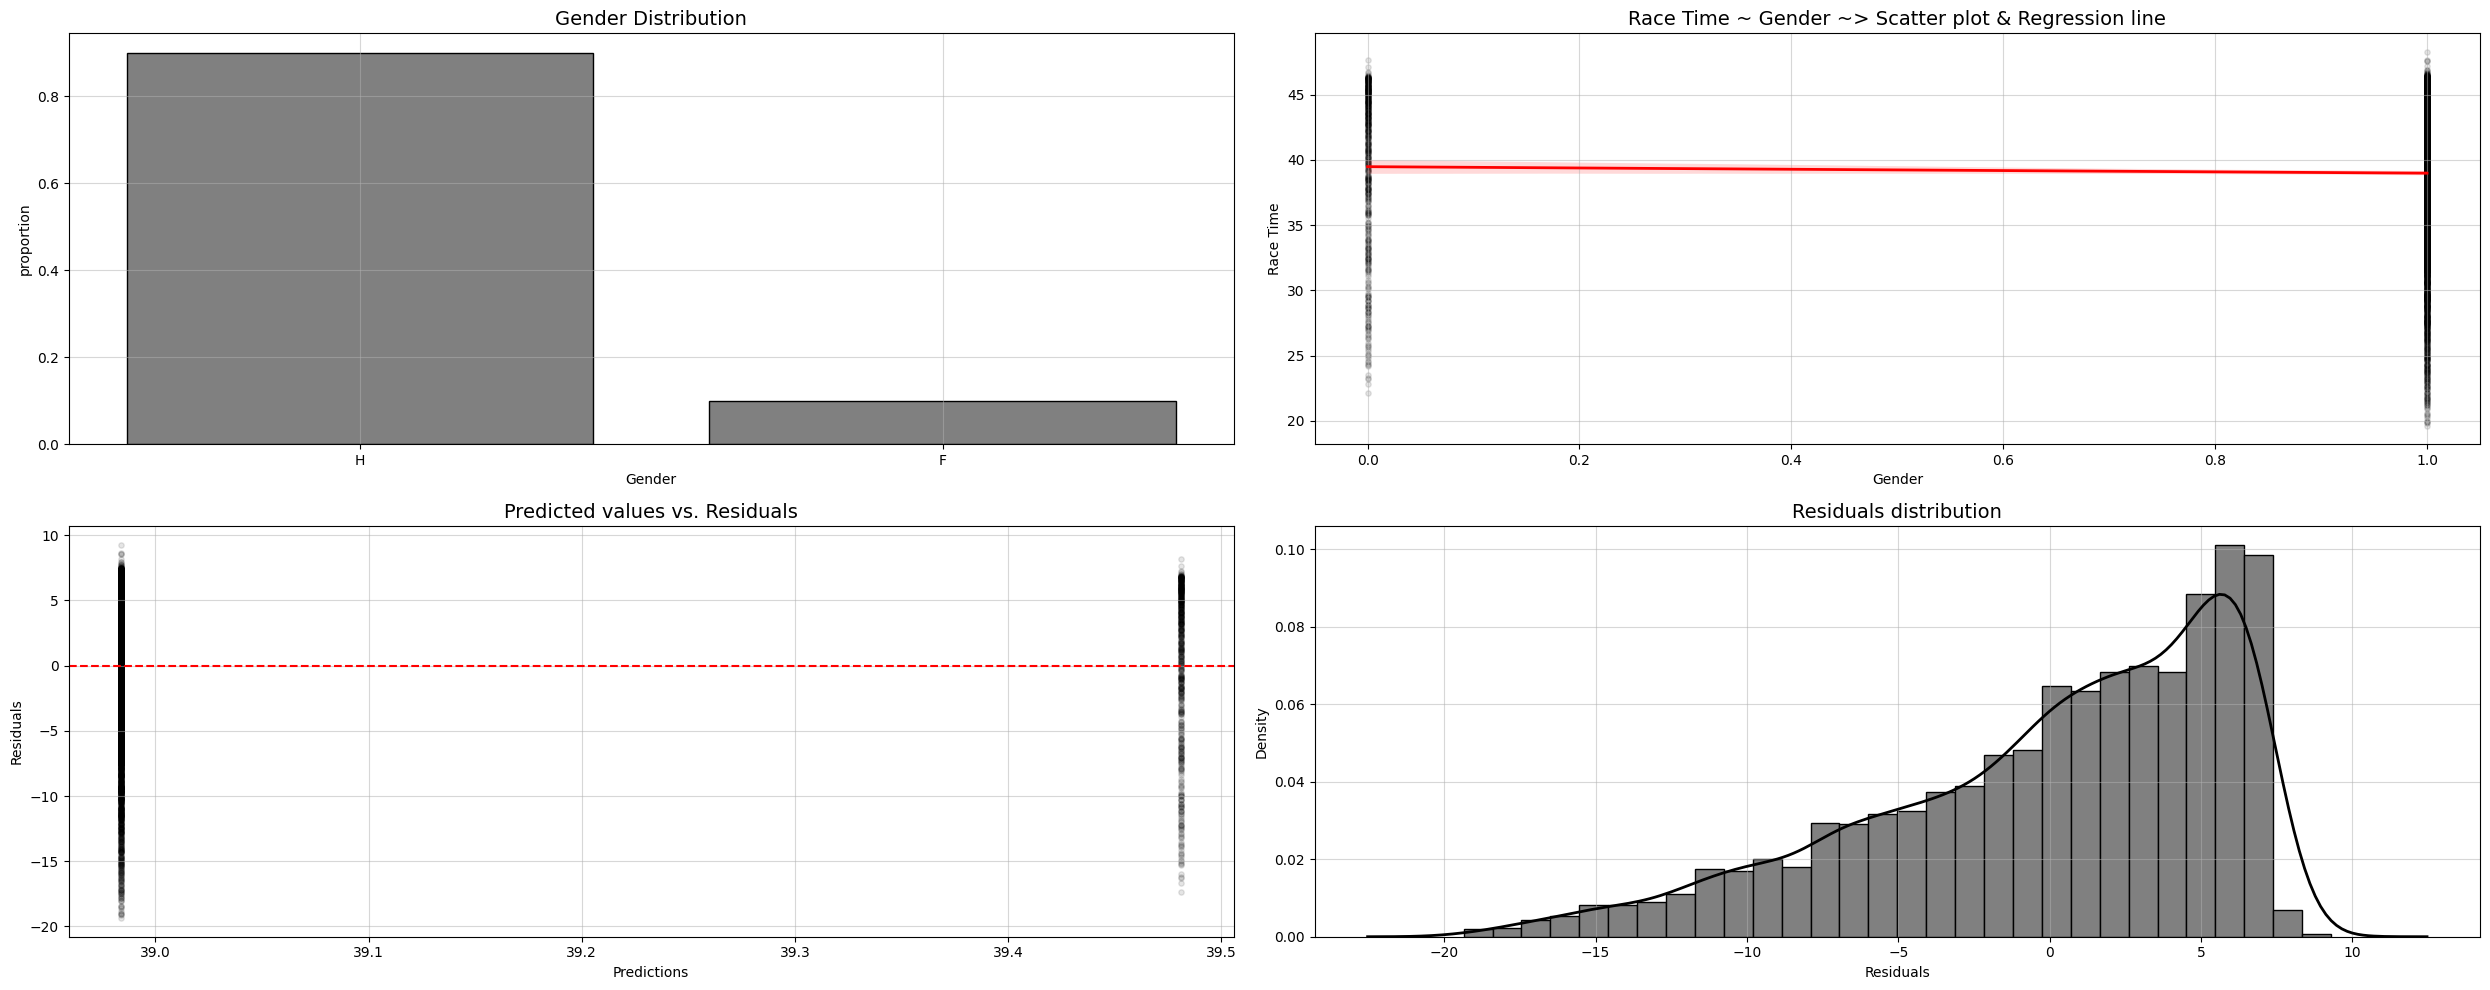

In [24]:
# Gender

_ = univariate_OLS_categorical(
    target = "runner_race_time_hours", target_name = "Race Time",
    feature = "runner_gender", feature_name = "Gender",
    data = race_results_runner_statistics_finished_train,
    alpha = 0.1,
    box_cox_transformation = False, 
    print_metrics = True,
    show_plot = True
    )

-----------------------------------------------------
Race Time ~ Pre-race UTMB index ~> Univariate Linear Regression
-----------------------------------------------------

proportion of clipped Box-Cox predicted values ~> None
coef ~> -0.0510
scaled coef ~> -0.8311
p-value ~> 0.0000
standard error ~> 0.0005
scaled standard error ~> 0.0077
confidence interval ~> ['-0.0520', '-0.0501']
scaled confidence interval ~> ['-0.8462', '-0.8160']
R2 ~> 0.6908
R2 adjusted ~> 0.6907
MAE ~> 2.5999
RMSE ~> 3.2791
Pearson correlation coefficient ~> 0.8311


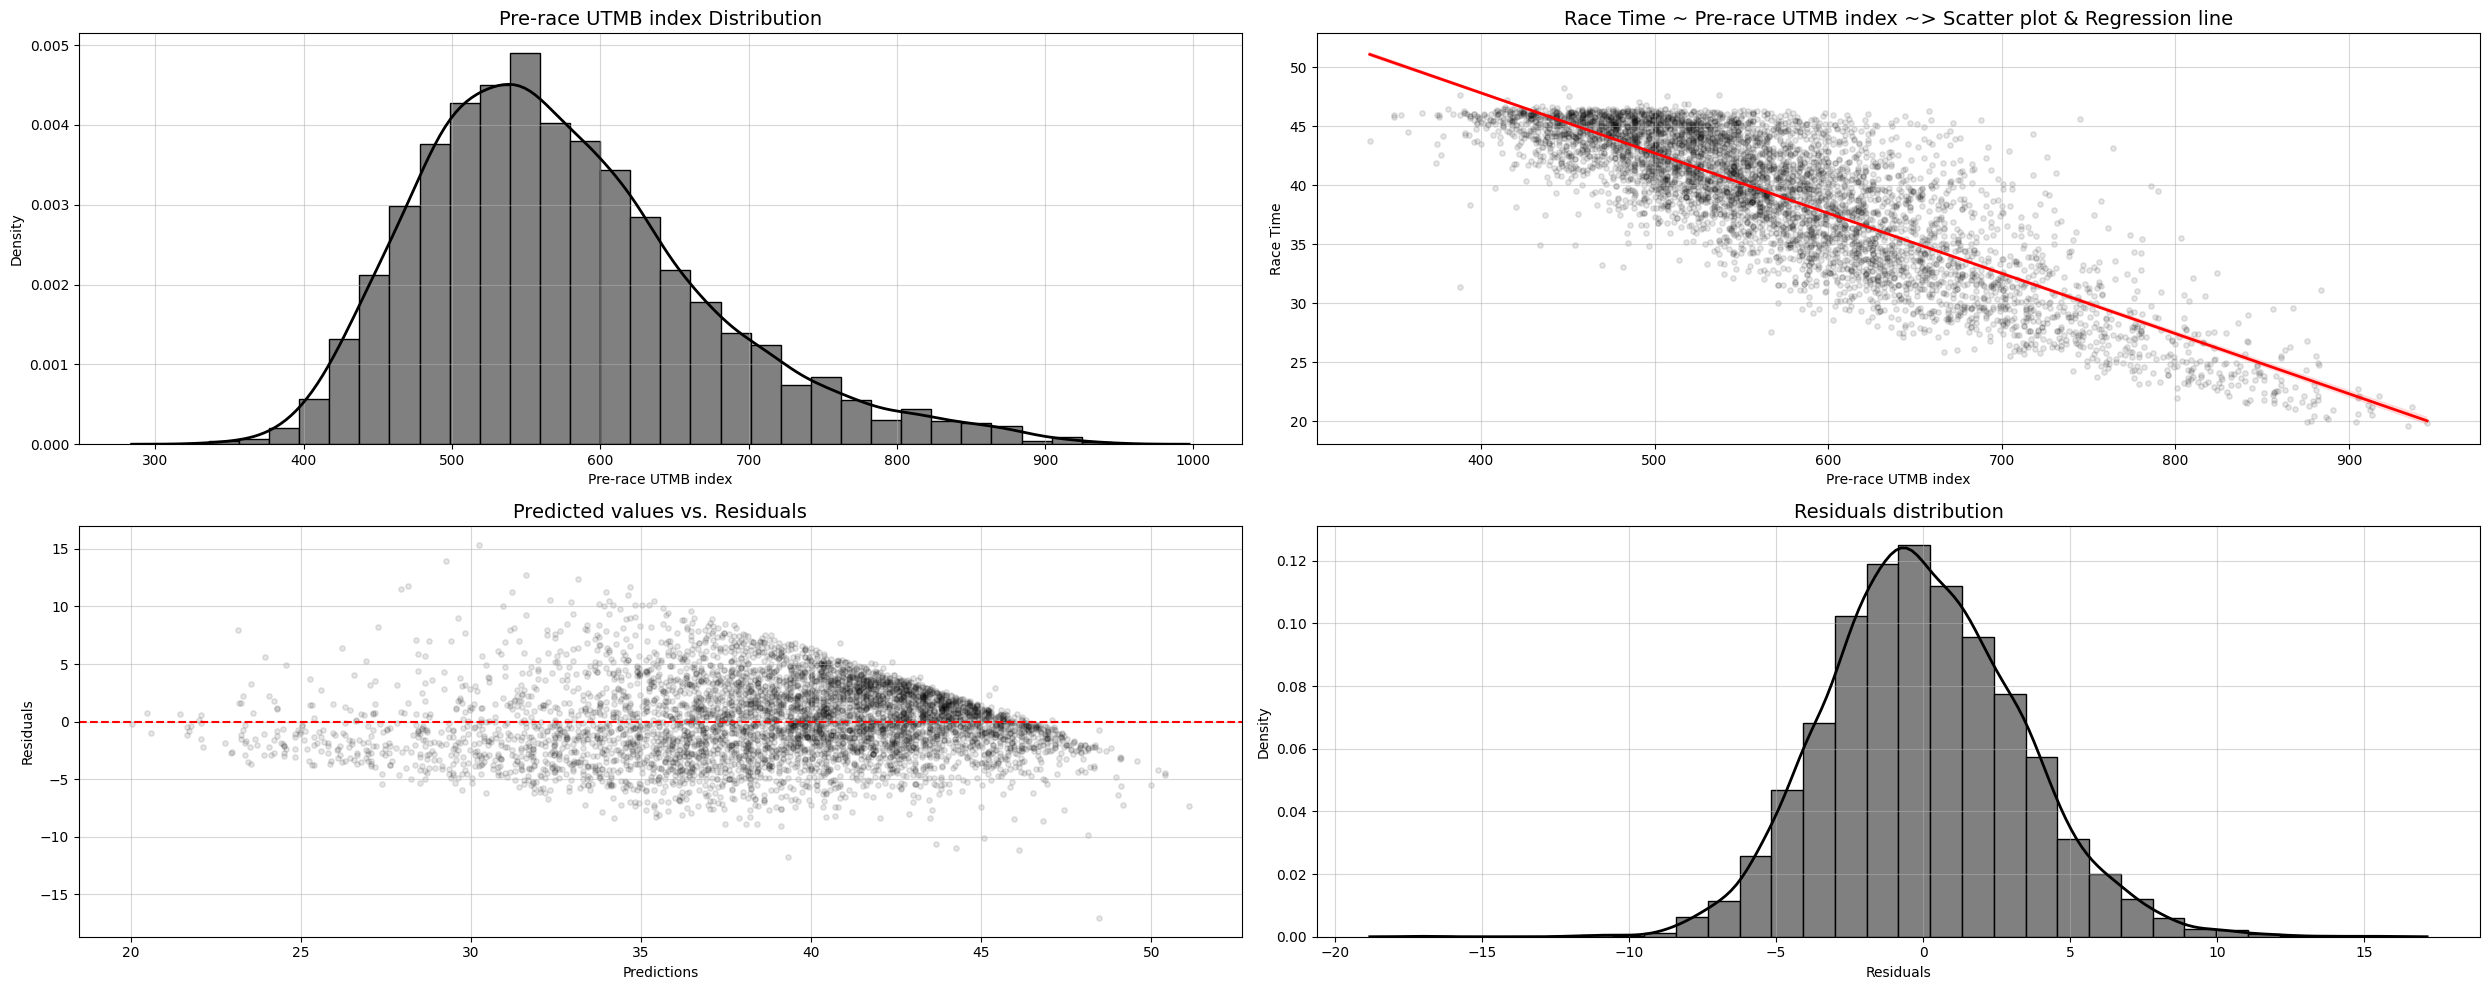

In [25]:
# Pre-race UTMB index

_ = univariate_OLS_numeric(
    target = "runner_race_time_hours", target_name = "Race Time",
    feature = "runner_pre_race_index", feature_name = "Pre-race UTMB index",
    data = race_results_runner_statistics_finished_train,
    alpha = 0.1,
    box_cox_transformation = False, 
    print_metrics = True,
    show_plot = True
    )

-----------------------------------------------------
Race Time ~ Last 2 years 100 miles average finisher rank score ~> Univariate Linear Regression
-----------------------------------------------------

proportion of clipped Box-Cox predicted values ~> None
coef ~> -16.7541
scaled coef ~> -0.7474
p-value ~> 0.0000
standard error ~> 0.2478
scaled standard error ~> 0.0111
confidence interval ~> ['-17.2399', '-16.2684']
scaled confidence interval ~> ['-0.7691', '-0.7257']
R2 ~> 0.5586
R2 adjusted ~> 0.5585
MAE ~> 3.1444
RMSE ~> 4.0627
Pearson correlation coefficient ~> 0.7474


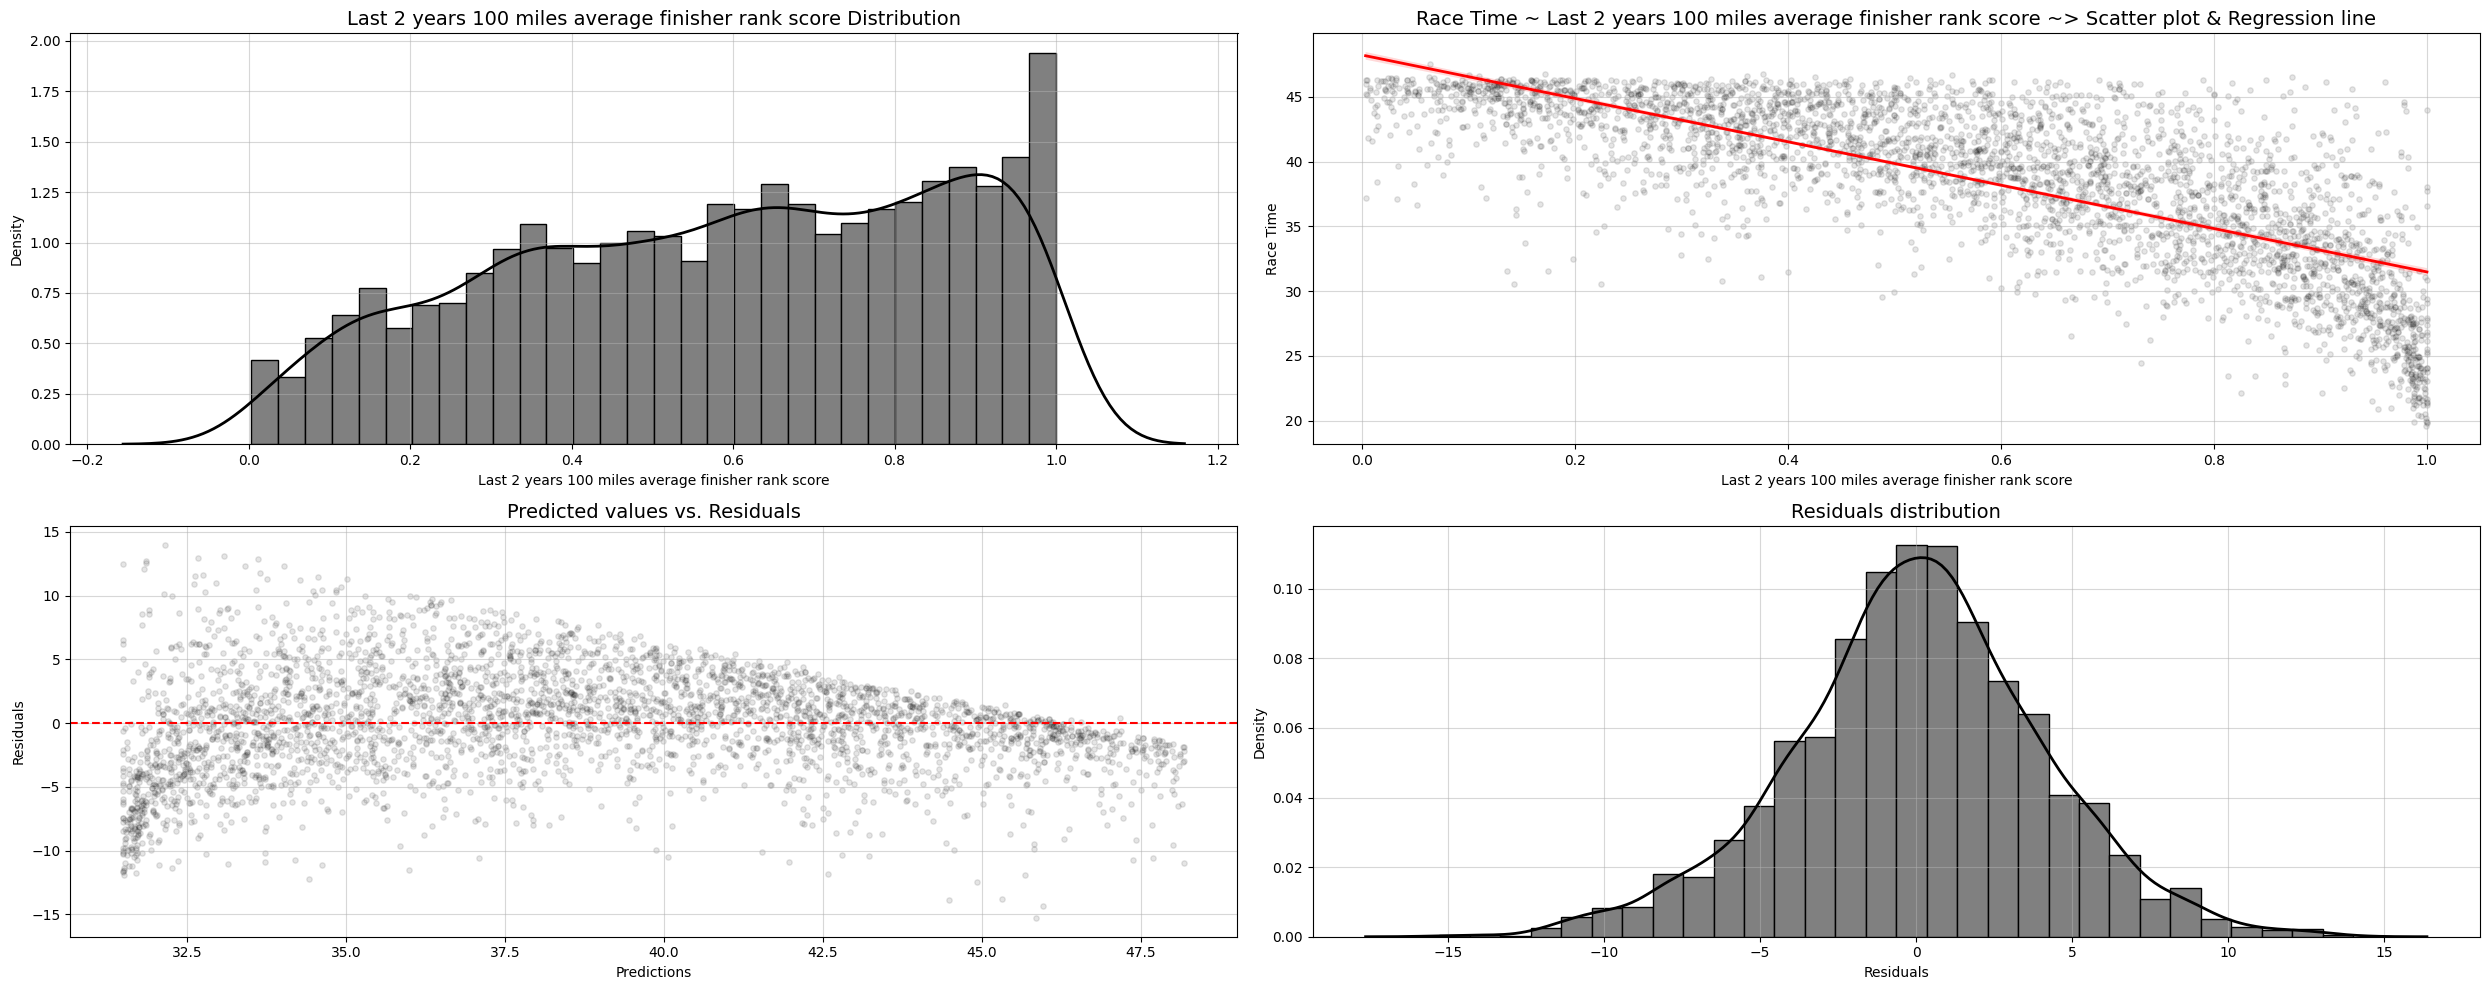

In [26]:
# Last 2 years 100 miles average finisher rank score

_ = univariate_OLS_numeric(
    target = "runner_race_time_hours", target_name = "Race Time",
    feature = "last2years_100m_avg_finisher_rank_prop", feature_name = "Last 2 years 100 miles average finisher rank score",
    data = race_results_runner_statistics_finished_train,
    alpha = 0.1,
    box_cox_transformation = False, 
    print_metrics = True,
    show_plot = True
    )

-----------------------------------------------------
Race Time ~ Last 2 years 100 miles average elevation gain adjusted pace ~> Univariate Linear Regression
-----------------------------------------------------

proportion of clipped Box-Cox predicted values ~> None
coef ~> 2.5527
scaled coef ~> 0.6944
p-value ~> 0.0000
standard error ~> 0.0440
scaled standard error ~> 0.0120
confidence interval ~> ['2.4664', '2.6389']
scaled confidence interval ~> ['0.6709', '0.7179']
R2 ~> 0.4822
R2 adjusted ~> 0.4820
MAE ~> 3.5760
RMSE ~> 4.4006
Pearson correlation coefficient ~> 0.6944


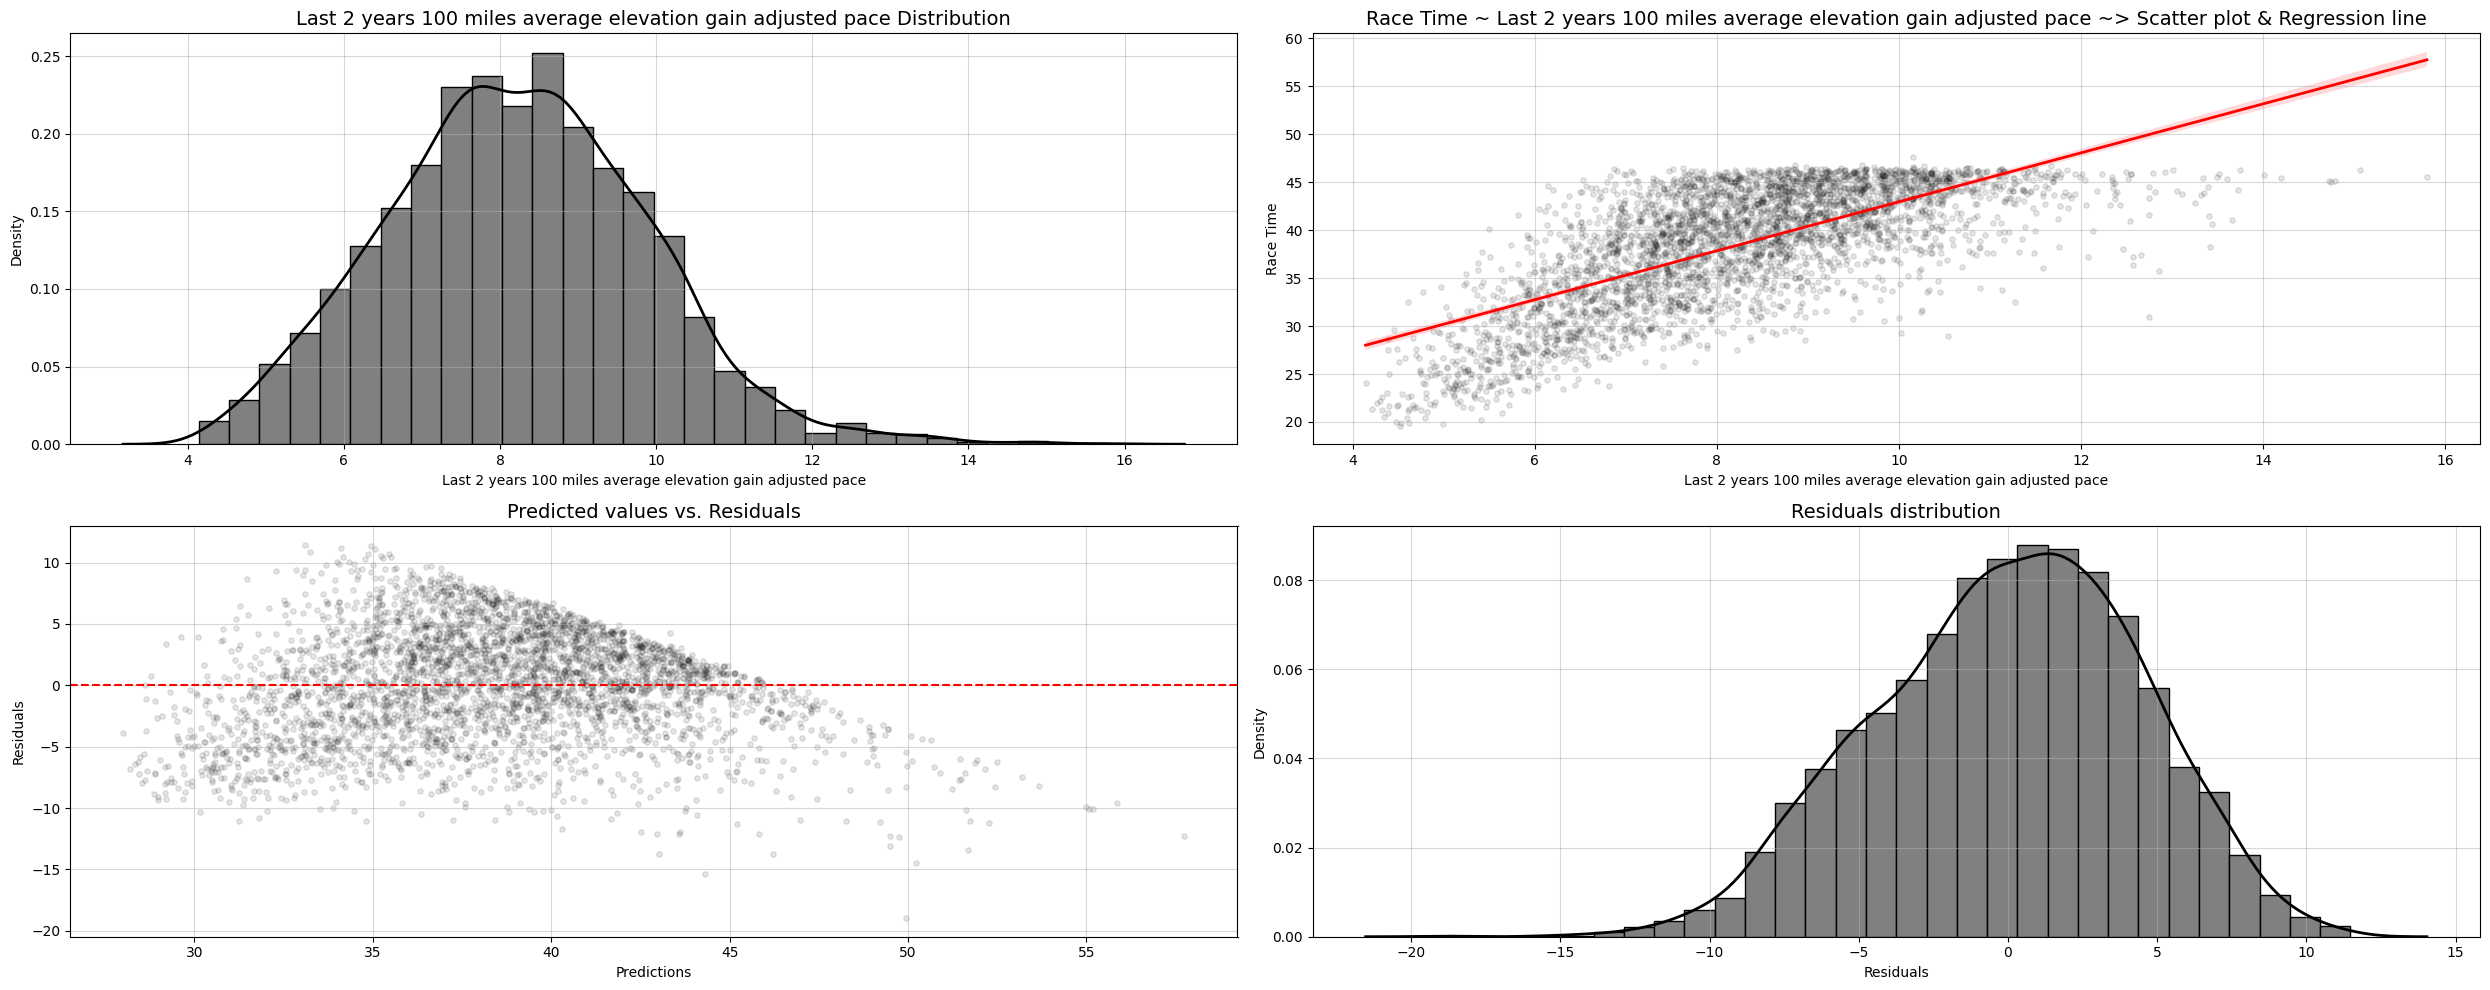

In [27]:
# Last 2 years 100 miles average elevation gain adjusted pace

_ = univariate_OLS_numeric(
    target = "runner_race_time_hours", target_name = "Race Time",
    feature = "last2years_100m_avg_elevation_gain_adjusted_pace", feature_name = "Last 2 years 100 miles average elevation gain adjusted pace",
    data = race_results_runner_statistics_finished_train,
    alpha = 0.1,
    box_cox_transformation = False, 
    print_metrics = True,
    show_plot = True
    )

-----------------------------------------------------
Race Time ~ Days from last 100 miles race (max 2 years) ~> Univariate Linear Regression
-----------------------------------------------------

proportion of clipped Box-Cox predicted values ~> None
coef ~> 0.0035
scaled coef ~> 0.0999
p-value ~> 0.0000
standard error ~> 0.0006
scaled standard error ~> 0.0161
confidence interval ~> ['0.0024', '0.0046']
scaled confidence interval ~> ['0.0684', '0.1313']
R2 ~> 0.0100
R2 adjusted ~> 0.0097
MAE ~> 4.9970
RMSE ~> 6.0647
Pearson correlation coefficient ~> 0.0999


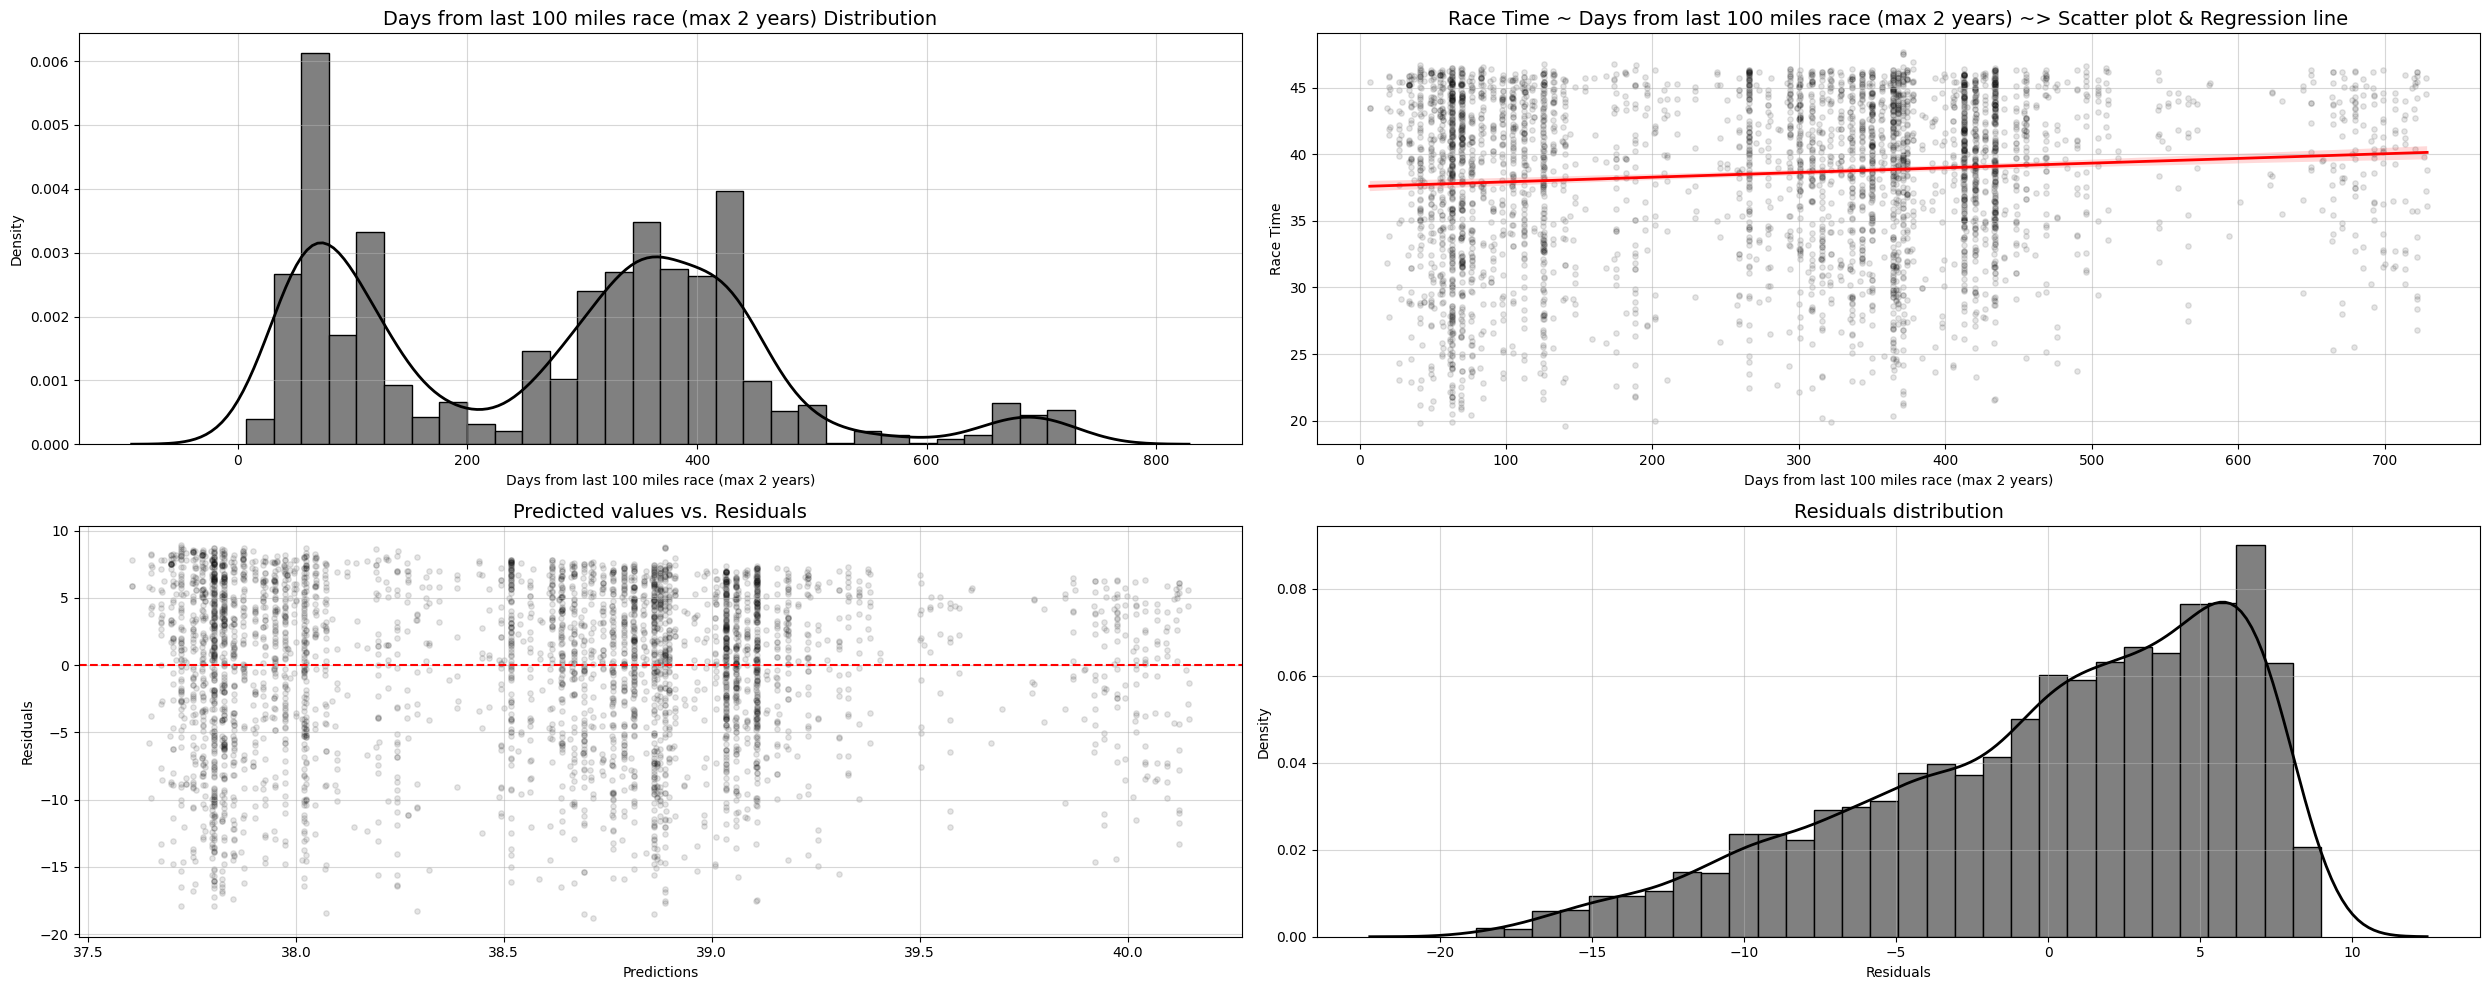

In [28]:
# Days from last 100 miles race (max 2 years)

_ = univariate_OLS_numeric(
    target = "runner_race_time_hours", target_name = "Race Time",
    feature = "last2years_100m_days_from_last_race", feature_name = "Days from last 100 miles race (max 2 years)",
    data = race_results_runner_statistics_finished_train,
    alpha = 0.1,
    box_cox_transformation = False, 
    print_metrics = True,
    show_plot = True
    )

---
### Race finish time ~ Full Linear model

Help functions

In [ ]:
# Full Train & Test OLS model ~ Help function

def full_OLS_model_analysis(
        target_dict: Dict[str, str],
        features_dict: Dict[str, str],
        train_data: pd.DataFrame, 
        test_data: pd.DataFrame,
        alpha: float=1.0,
        box_cox_transformation: bool=False, 
        print_metrics: bool=True,
        show_plot: bool=True
        ) -> Dict[str, any]:

    # -------------------------------------------------------------
    # -------------------------------------------------------------

    target = list(target_dict.keys())[0]
    target_name = list(target_dict.values())[0]

    features = list(features_dict.keys())
    features_names = list(features_dict.values())
        
    if (print_metrics or show_plot) == True:
        print("-----------------------------------------------------")
        print(f"{target_name} ~\n{" + \n".join(features_names)} \n~> Linear regression")
        print("-----------------------------------------------------\n")

    # Prepare data for modeling
    train_data = train_data.copy()
    test_data = test_data.copy()

    if box_cox_transformation:
        target_name = target_name + " [Box-Cox Transformed]"
        target_bc = train_data[target]
        lambda_bc = boxcox_normmax(target_bc)
        train_data[target+"_bc"] = boxcox(train_data[target], lmbda=lambda_bc)
        test_data[target+"_bc"] = boxcox(test_data[target], lmbda=lambda_bc)
        target = target+"_bc"

    train_data_clean = train_data[[target] + features].replace([np.inf, -np.inf], np.nan).dropna()
    X_train = sm.add_constant(train_data_clean[features])
    y_train = train_data_clean[target]

    test_data_clean = test_data[[target] + features].dropna() 
    X_test = sm.add_constant(test_data_clean[features])
    y_test = test_data_clean[target]

    # Model
    model = sm.OLS(y_train, X_train)
    fit = model.fit()

    y_pred_train = fit.predict(X_train)
    y_pred_test = fit.predict(X_test)

    if box_cox_transformation:
        prop_clipped_train = round((y_pred_train < 1e-6).mean(), 2)
        y_pred_train = np.where(y_pred_train < 1e-6, 1e-6, y_pred_train)
        y_pred_train = inv_boxcox(y_pred_train, lambda_bc)
        y_train = inv_boxcox(y_train, lambda_bc)

        prop_clipped_test = round((y_pred_test < 1e-6).mean(), 2)
        y_pred_test = np.where(y_pred_test < 1e-6, 1e-6, y_pred_test)
        y_pred_test = inv_boxcox(y_pred_test, lambda_bc)
        y_test = inv_boxcox(y_test, lambda_bc)

    # Metrics
    X_train_no_const = X_train.drop(columns="const", errors="ignore").copy()
    vif_train = pd.DataFrame({
        "feature": X_train_no_const.columns,
        "VIF": [variance_inflation_factor(X_train_no_const.values, i) for i in range(X_train_no_const.shape[1])]
        })

    train_model_metrics = {
        "proportion of clipped Box-Cox predicted values": prop_clipped_train if box_cox_transformation else None,
        "R2": fit.rsquared,
        "R2 adjusted": fit.rsquared_adj,
        "MAE": mean_absolute_error(y_train, y_pred_train),
        "RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "Pearson correlation coefficient": pearsonr(y_train, y_pred_train)[0],
        "mean VIF": vif_train["VIF"].mean(),
        "max VIF": vif_train["VIF"].max(),
    }
    train_model_metrics_df = pd.DataFrame([train_model_metrics])

    test_model_metrics = {
        "proportion of clipped Box-Cox predicted values": prop_clipped_test if box_cox_transformation else None,
        "R2": r2_score(y_test, y_pred_test),
        "MAE": mean_absolute_error(y_test, y_pred_test),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "Pearson correlation coefficient": pearsonr(y_test, y_pred_test)[0],
    }
    test_model_metrics_df = pd.DataFrame([test_model_metrics])

    features_metrics = []
    for single_feature in features:
        scaling_factor = np.std(train_data_clean[single_feature]) / np.std(train_data_clean[target])
        single_feature_metrics = {
            "feature": single_feature,
            "feature name": features_dict[single_feature],
            "coef": fit.params[single_feature],
            "scaled coef": fit.params[single_feature] * scaling_factor,
            "p-value": fit.pvalues[single_feature],
            "standard error": fit.bse[single_feature],
            "scaled standard error": fit.bse[single_feature] * scaling_factor,
            "confidence interval": round(fit.conf_int().loc[single_feature], 4).tolist(),
            "scaled confidence interval": round(fit.conf_int().loc[single_feature] * scaling_factor, 4).tolist(),
            "VIF": vif_train.loc[vif_train["feature"] == single_feature, "VIF"].values[0]
        }
        features_metrics.append(single_feature_metrics)
    features_metrics_df = pd.DataFrame(features_metrics)

    if print_metrics:

        print("\nModel metrics on Train data:")
        print("------------------------------------")
        for key, value in train_model_metrics.items():
            if isinstance(value, list):
                print(f"{key} ~> {[f'{v:.4f}' for v in value]}")
            else:
                print(f"{key} ~> {value:.4f}" if isinstance(value, float) else f"{key} ~> {value}")

        print("\nModel metrics on Test data:")
        print("------------------------------------")
        for key, value in test_model_metrics.items():
            if isinstance(value, list):
                print(f"{key} ~> {[f'{v:.4f}' for v in value]}")
            else:
                print(f"{key} ~> {value:.4f}" if isinstance(value, float) else f"{key} ~> {value}")

        print("\nFeatures metrics:")
        display(features_metrics_df)

    # Plot
    if show_plot:
        fig, ax = plt.subplots(2, 2, figsize=(25, 10))

        # Scatter plot with regression line
        ax[0,0].set_title("Scatter plot & Regression line ~ Test data", fontsize=14)
        ax[0,0].scatter(y_pred_test, y_test, color="black", s=15, alpha=alpha)
        sns.regplot(x=y_pred_test, y=y_test, ax=ax[0,0], scatter=False, line_kws={"color":"red", "linewidth":2}, label="Regression line")
        ax[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="blue", linewidth=2, linestyle="--", label="Perfect line [x=y]")
        ax[0,0].set_xlabel("Predictions")
        ax[0,0].set_ylabel("Actual values")
        ax[0,0].legend()

        # Predicted values and actual values distribution on Test data
        ax[0,1].set_title("Predicted & Actual values distribution ~ Test data", fontsize=14)
        residuals_train = y_train - y_pred_train
        ax[0,1].hist(y_pred_test, bins=30, density=True, color="red", edgecolor="red", alpha=0.3)
        sns.kdeplot(y_pred_test, ax=ax[0,1], color="red", linewidth=2, label="Predictions")
        ax[0,1].hist(y_test, bins=30, density=True, color="blue", edgecolor="blue", alpha=0.3)
        sns.kdeplot(y_test, ax=ax[0,1], color="blue", linewidth=2, label="Actuals")
        ax[0,1].set_xlabel("Residuals")
        ax[0,1].set_ylabel("Density")
        ax[0,1].legend()

        # Residuals scatter on Train data ~ Linearity assumption, Homoscedasticity, Outliers, Centering around zero
        ax[1,0].set_title("Predicted values vs. Residuals ~ Train data", fontsize=14)
        residuals_train = y_train - y_pred_train
        ax[1,0].scatter(y_pred_train, residuals_train, color="black", s=15, alpha=alpha)
        ax[1,0].axhline(0, color="red", linestyle="--")
        ax[1,0].set_xlabel(f"Predicted")
        ax[1,0].set_ylabel("Residuals")

        # Residuals KDE ~ Normality assumption
        ax[1,1].set_title("Residuals distribution ~ Train data", fontsize=14)
        residuals_train = y_train - y_pred_train
        ax[1,1].hist(residuals_train, bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
        sns.kdeplot(residuals_train, ax=ax[1,1], color="black", linewidth=2)
        ax[1,1].set_xlabel("Residuals")
        ax[1,1].set_ylabel("Density")

        for i in [0,1]:
            for j in [0,1]:
                ax[i,j].grid(alpha=.5)

        plt.tight_layout()
        plt.show()

    # Return
    metrics = {
        "fit": fit,
        "features": features,
        "train_model_metrics": train_model_metrics_df,
        "test_model_metrics": test_model_metrics_df,
        "features_metrics": features_metrics_df,
    }

    return metrics


Prepare dummies

In [30]:
# Gender
race_results_runner_statistics_finished_train["runner_gender_H"] = np.where(race_results_runner_statistics_finished_train["runner_gender"] == "H", 1, 0)
race_results_runner_statistics_finished_test["runner_gender_H"] = np.where(race_results_runner_statistics_finished_test["runner_gender"] == "H", 1, 0)

Model

-----------------------------------------------------
Race Time ~
Pre-race UTMB index + 
Last 2 years 100 miles average finisher rank score + 
Days from last 100 miles race (max 2 years) 
~> Linear regression
-----------------------------------------------------


Model metrics on Train data:
------------------------------------
proportion of clipped Box-Cox predicted values ~> None
R2 ~> 0.7405
R2 adjusted ~> 0.7403
MAE ~> 2.4622
RMSE ~> 3.1150
Pearson correlation coefficient ~> 0.8605
mean VIF ~> 9.2211
max VIF ~> 14.1796

Model metrics on Test data:
------------------------------------
proportion of clipped Box-Cox predicted values ~> None
R2 ~> 0.7427
MAE ~> 2.5743
RMSE ~> 3.2272
Pearson correlation coefficient ~> 0.8622

Features metrics:


,feature,feature name,coef,scaled coef,p-value,standard error,scaled standard error,confidence interval,scaled confidence interval,VIF
0,runner_pre_race_index,Pre-race UTMB index,-0.040911,-0.656168,0.000000e+00,0.000819,0.013133,"[-0.0425, -0.0393]","[-0.6819, -0.6304]",14.179568
1,last2years_100m_avg_finisher_rank_prop,Last 2 years 100 miles average finisher rank s...,-5.560362,-0.247993,3.833018e-76,0.293994,0.013112,"[-6.1368, -4.984]","[-0.2737, -0.2223]",10.266696
2,last2years_100m_days_from_last_race,Days from last 100 miles race (max 2 years),0.000051,0.001446,8.655737e-01,0.000303,0.008539,"[-0.0005, 0.0006]","[-0.0153, 0.0182]",3.216952


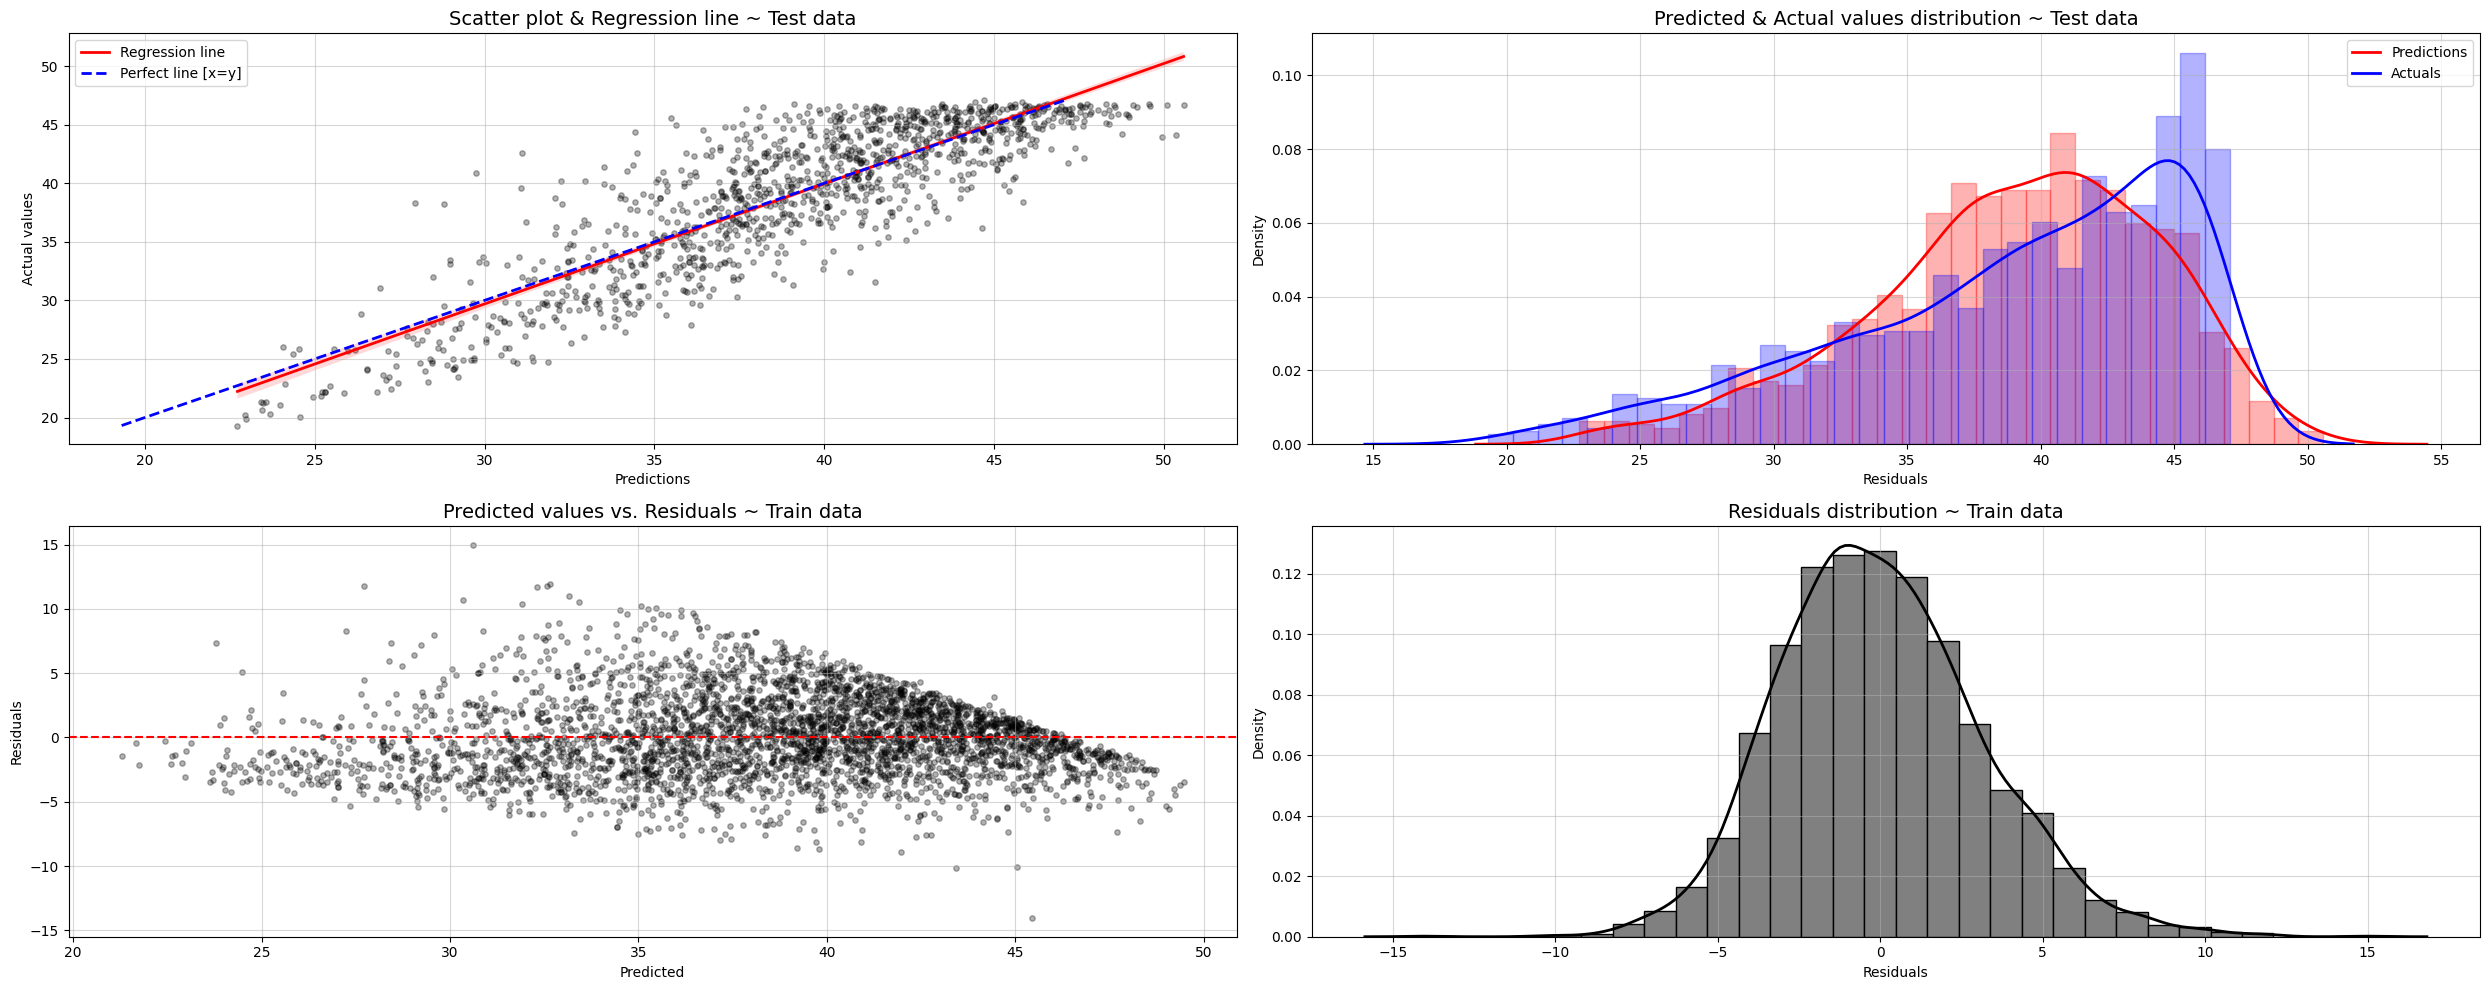

In [31]:
# Model
features_dict = {
    "runner_pre_race_index": "Pre-race UTMB index", 
    "last2years_100m_avg_finisher_rank_prop": "Last 2 years 100 miles average finisher rank score", 
    "last2years_100m_days_from_last_race": "Days from last 100 miles race (max 2 years)",
    }

_ = full_OLS_model_analysis(
    target_dict = {"runner_race_time_hours": "Race Time"},
    features_dict = features_dict,
    train_data = race_results_runner_statistics_finished_train, 
    test_data = race_results_runner_statistics_finished_test,
    alpha = 0.3,
    box_cox_transformation = False,
    print_metrics = True,
    show_plot = True
    )

-----------------------------------------------------
Race Time ~
Pre-race UTMB index + 
Last 2 years 100 miles average finisher rank score 
~> Linear regression
-----------------------------------------------------


Model metrics on Train data:
------------------------------------
proportion of clipped Box-Cox predicted values ~> None
R2 ~> 0.7405
R2 adjusted ~> 0.7404
MAE ~> 2.4622
RMSE ~> 3.1151
Pearson correlation coefficient ~> 0.8605
mean VIF ~> 9.8626
max VIF ~> 9.8626

Model metrics on Test data:
------------------------------------
proportion of clipped Box-Cox predicted values ~> None
R2 ~> 0.7428
MAE ~> 2.5740
RMSE ~> 3.2267
Pearson correlation coefficient ~> 0.8622

Features metrics:


,feature,feature name,coef,scaled coef,p-value,standard error,scaled standard error,confidence interval,scaled confidence interval,VIF
0,runner_pre_race_index,Pre-race UTMB index,-0.040920,-0.656301,0.000000e+00,0.000817,0.013108,"[-0.0425, -0.0393]","[-0.682, -0.6306]",9.86257
1,last2years_100m_avg_finisher_rank_prop,Last 2 years 100 miles average finisher rank s...,-5.561304,-0.248035,3.266543e-76,0.293902,0.013108,"[-6.1375, -4.9851]","[-0.2737, -0.2223]",9.86257


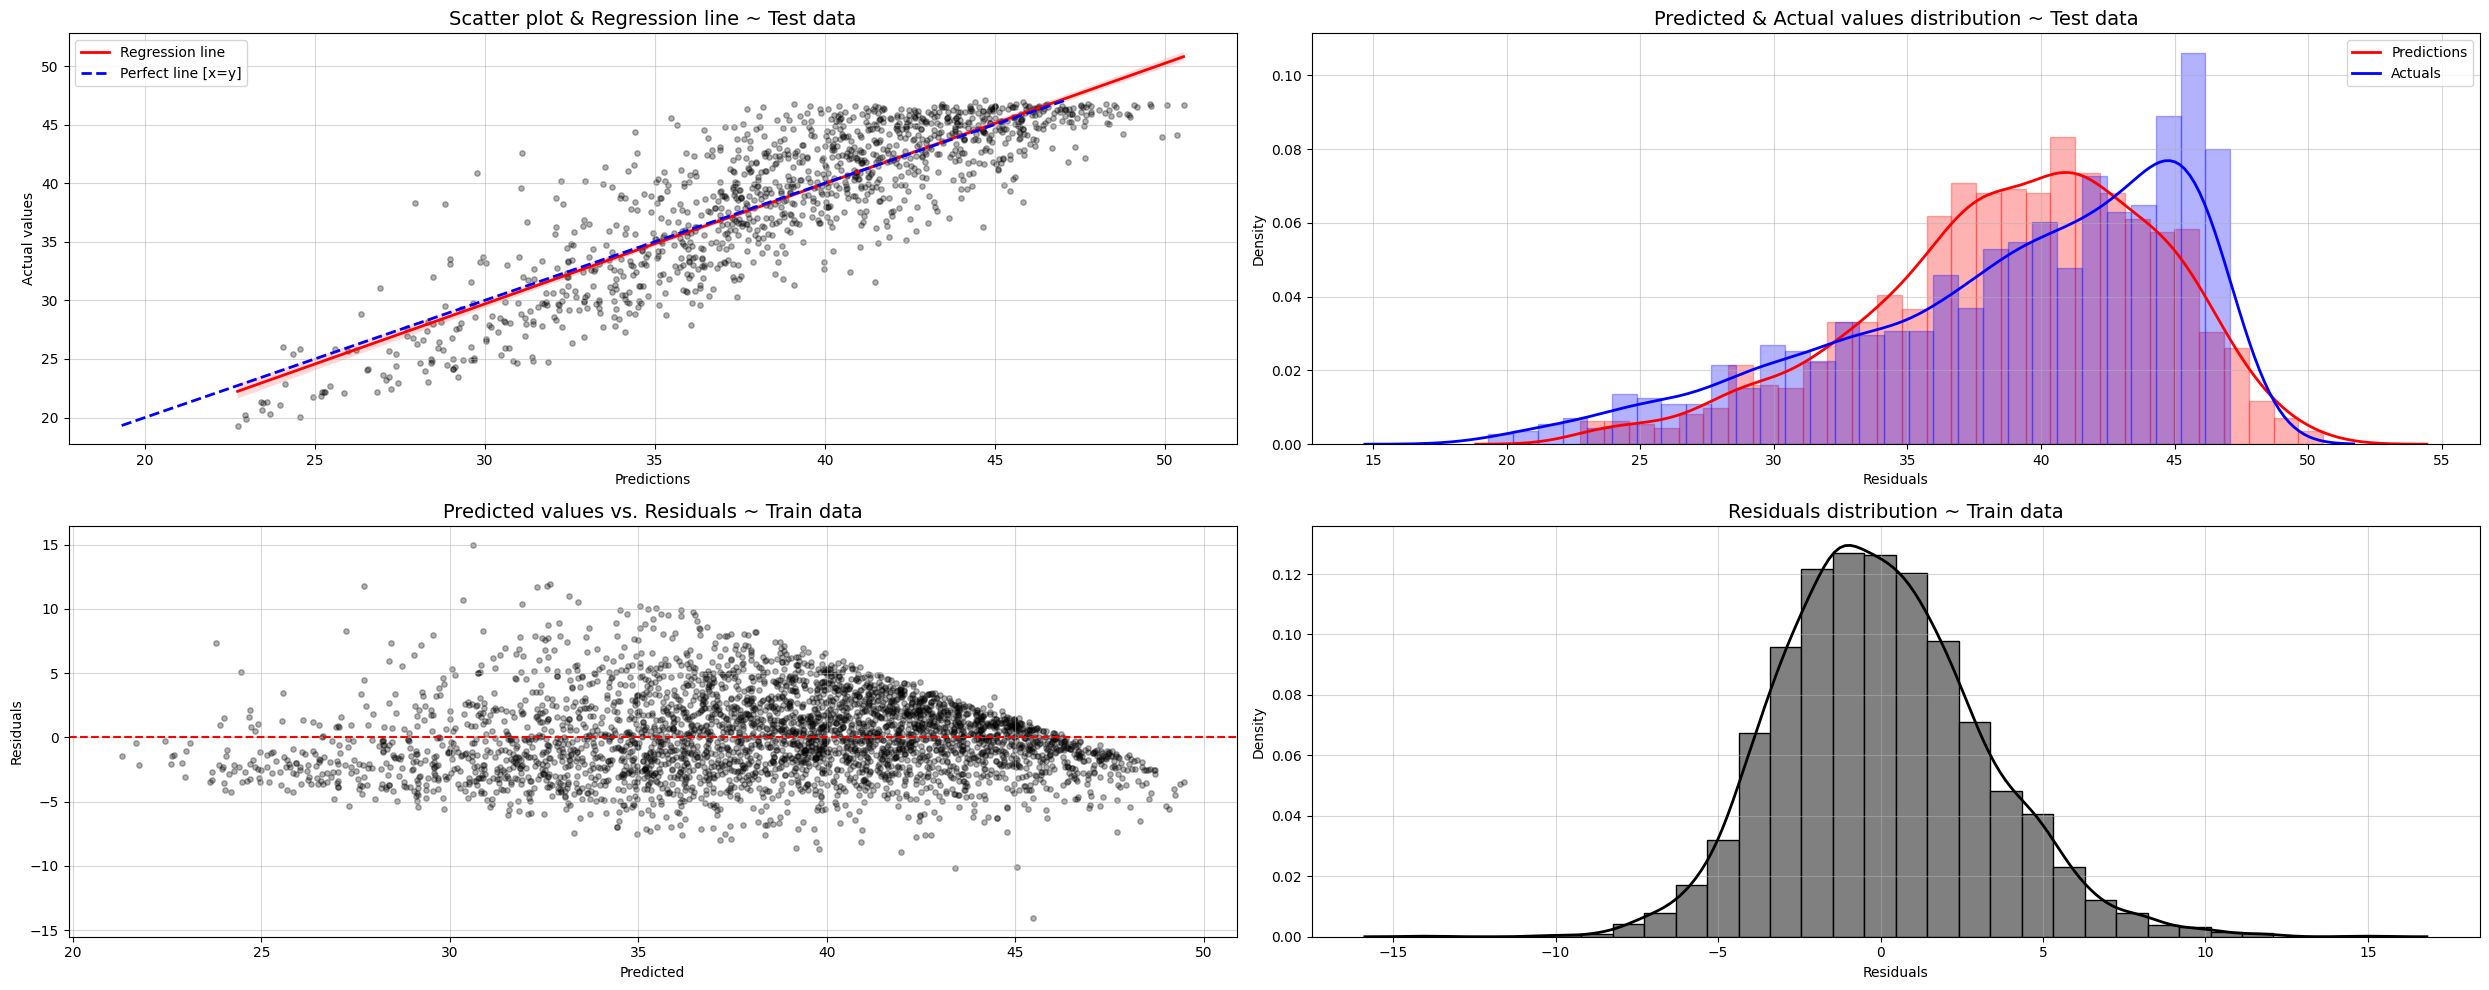

In [32]:
# Model
features_dict = {
    "runner_pre_race_index": "Pre-race UTMB index", 
    "last2years_100m_avg_finisher_rank_prop": "Last 2 years 100 miles average finisher rank score", 
    }

_ = full_OLS_model_analysis(
    target_dict = {"runner_race_time_hours": "Race Time"},
    features_dict = features_dict,
    train_data = race_results_runner_statistics_finished_train, 
    test_data = race_results_runner_statistics_finished_test,
    alpha = 0.3,
    box_cox_transformation = False,
    print_metrics = True,
    show_plot = True
    )

-----------------------------------------------------
Race Time ~
Pre-race UTMB index + 
Last 2 years 100 miles average finisher rank score + 
Last 2 years 100 miles average finisher rank score in gender + 
Last 2 years 100 km average elevation gain adjusted pace + 
All time 100 miles UTMB index trend + 
Age + 
Gender Male 
~> Linear regression
-----------------------------------------------------


Model metrics on Train data:
------------------------------------
proportion of clipped Box-Cox predicted values ~> None
R2 ~> 0.7620
R2 adjusted ~> 0.7614
MAE ~> 2.4094
RMSE ~> 3.0513
Pearson correlation coefficient ~> 0.8729
mean VIF ~> 91.9428
max VIF ~> 263.6386

Model metrics on Test data:
------------------------------------
proportion of clipped Box-Cox predicted values ~> None
R2 ~> 0.7639
MAE ~> 2.4973
RMSE ~> 3.1380
Pearson correlation coefficient ~> 0.8740

Features metrics:


,feature,feature name,coef,scaled coef,p-value,standard error,scaled standard error,confidence interval,scaled confidence interval,VIF
0,runner_pre_race_index,Pre-race UTMB index,-0.036534,-0.577284,4.786452e-192,0.001142,0.018044,"[-0.0388, -0.0343]","[-0.6127, -0.5419]",47.834569
1,last2years_100m_avg_finisher_rank_prop,Last 2 years 100 miles average finisher rank s...,-3.832669,-0.166534,6.879949e-03,1.417104,0.061575,"[-6.6113, -1.054]","[-0.2873, -0.0458]",261.314607
2,last2years_100m_avg_finisher_rank_prop_gender,Last 2 years 100 miles average finisher rank s...,-1.397584,-0.061016,3.253261e-01,1.420681,0.062024,"[-4.1833, 1.3881]","[-0.1826, 0.0606]",263.638562
3,last2years_100k_avg_elevation_gain_adjusted_pace,Last 2 years 100 km average elevation gain adj...,0.542181,0.114115,8.022518e-14,0.072219,0.015200,"[0.4006, 0.6838]","[0.0843, 0.1439]",25.390947
4,alltime_100m_utmb_index_trend,All time 100 miles UTMB index trend,-0.001035,-0.010036,2.761889e-01,0.000950,0.009214,"[-0.0029, 0.0008]","[-0.0281, 0.008]",1.019232
5,runner_age,Age,0.026988,0.035424,3.815461e-04,0.007588,0.009959,"[0.0121, 0.0419]","[0.0159, 0.055]",30.587128
6,runner_gender_H,Gender Male,0.042795,0.002082,8.500581e-01,0.226357,0.011014,"[-0.401, 0.4866]","[-0.0195, 0.0237]",13.814824


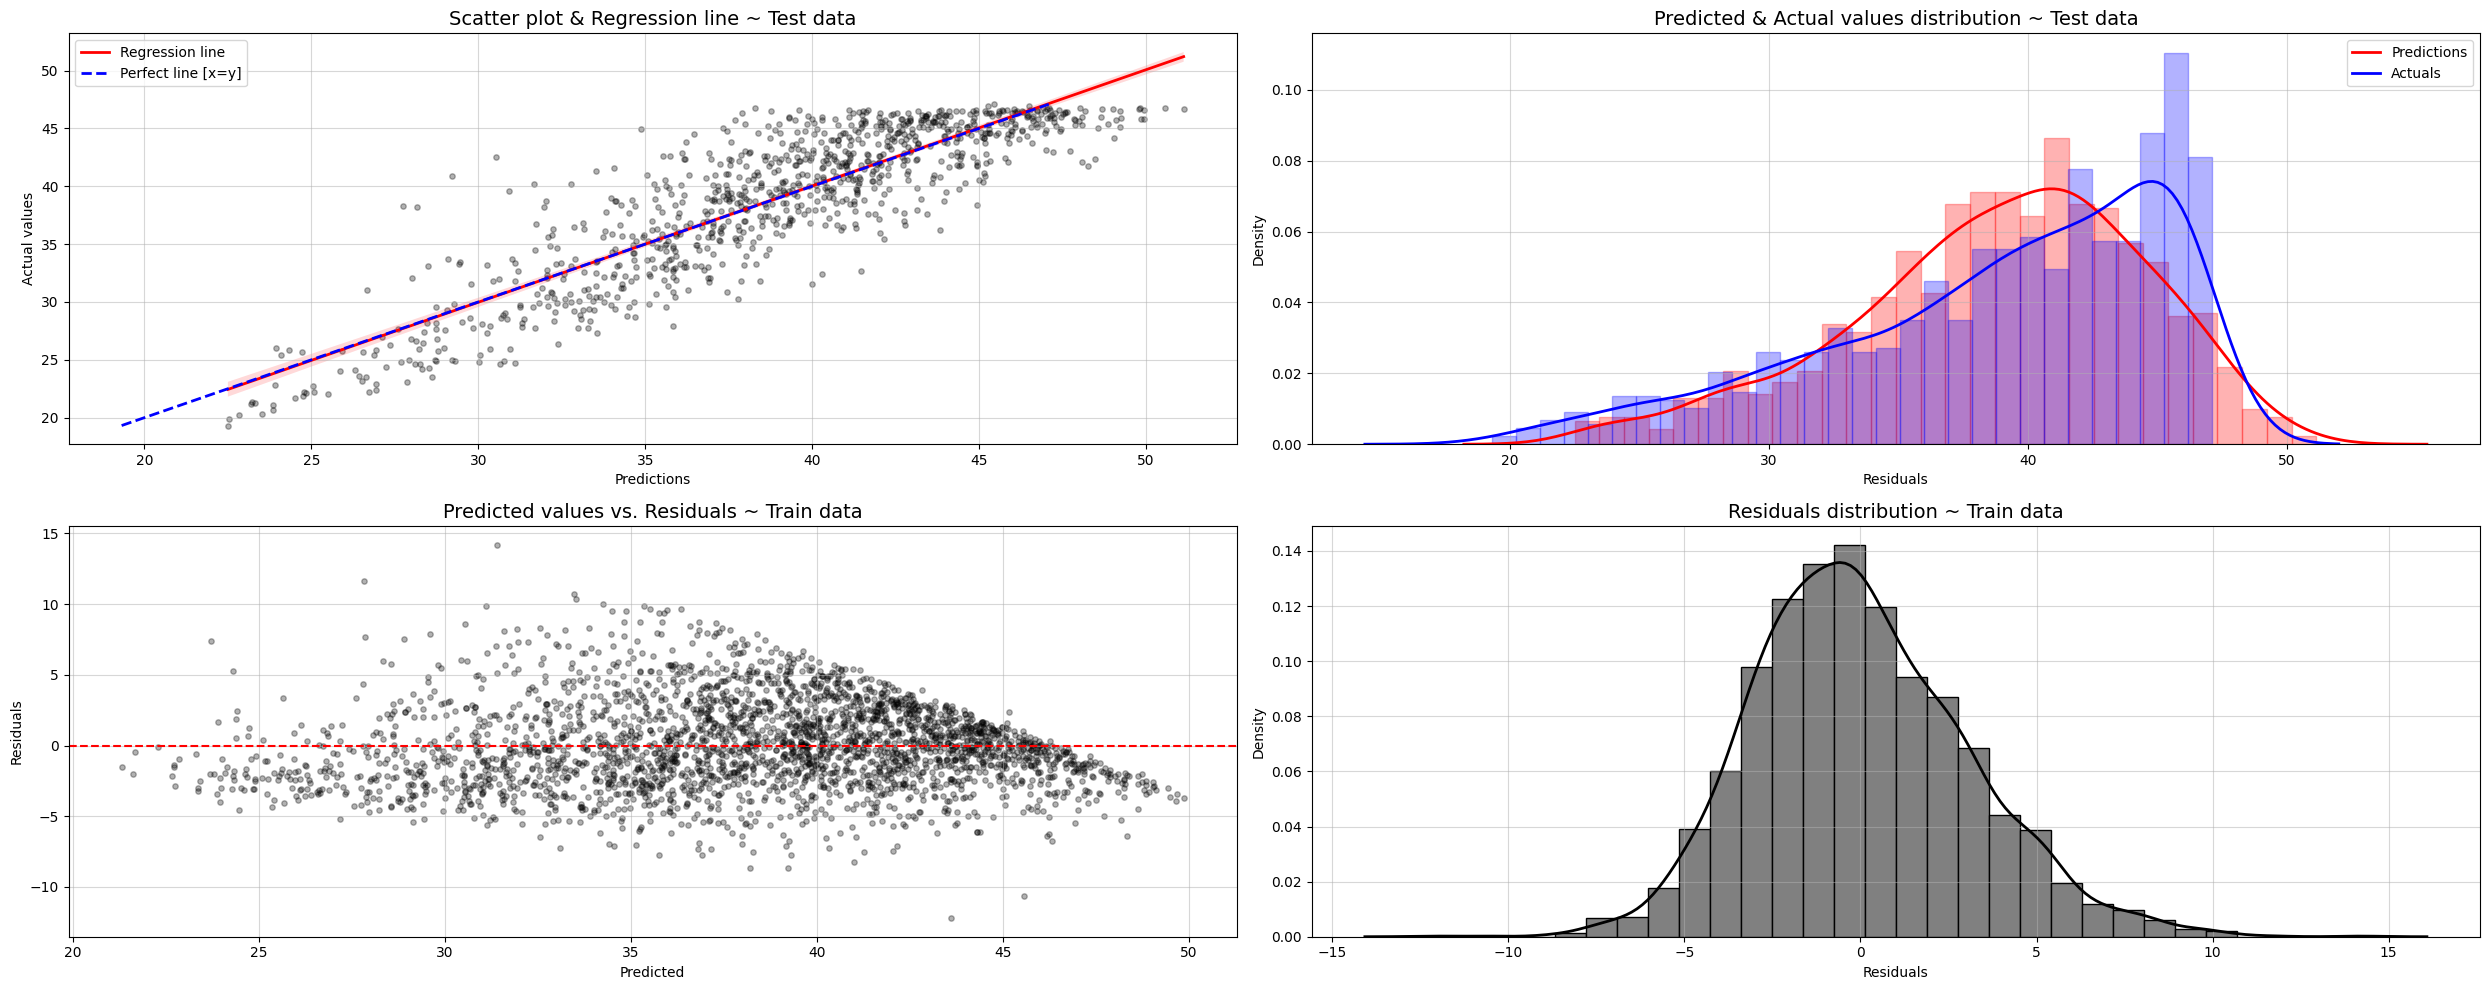

In [33]:
# Model
features_dict = {
    "runner_pre_race_index": "Pre-race UTMB index", 
    "last2years_100m_avg_finisher_rank_prop": "Last 2 years 100 miles average finisher rank score", 
    "last2years_100m_avg_finisher_rank_prop_gender": "Last 2 years 100 miles average finisher rank score in gender", 
    "last2years_100k_avg_elevation_gain_adjusted_pace": "Last 2 years 100 km average elevation gain adjusted pace", 
    "alltime_100m_utmb_index_trend": "All time 100 miles UTMB index trend",
    "runner_age": "Age",
    "runner_gender_H": "Gender Male"
    }

_ = full_OLS_model_analysis(
    target_dict = {"runner_race_time_hours": "Race Time"},
    features_dict = features_dict,
    train_data = race_results_runner_statistics_finished_train, 
    test_data = race_results_runner_statistics_finished_test,
    alpha = 0.3,
    box_cox_transformation = False,
    print_metrics = True,
    show_plot = True
    )

In [34]:
# Model building
